# Laser OFF Code

In [6]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()})

SyntaxError: unterminated string literal (detected at line 3) (3993430197.py, line 3)

# Import

In [41]:
from qcodes.parameters import MultiParameter
import numpy as np
from qcodes import Parameter
import sys
from time import sleep
import pyvisa
from qcodes.dataset import Measurement
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
import qcodes as qc

In [274]:
from qcodes.dataset import Measurement
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
initialise_or_create_database_at("./2026-03-10_SNSPD3.db")

from time import sleep, monotonic

# Set up experiment
exp_name = 'SNSPD3_10_03_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 0


In [341]:
def count_rate_two(MS,bin_length, n_captures):
    # # Initialisation? 
    MS.write("SEARCH:SEARCH1:STATE 0")
    MS.write("SEARCH:SEARCH1:STATE 1")
    MS.write("SEARCH:SEARCH2:STATE 0")
    MS.write("SEARCH:SEARCH2:STATE 1")

    print(f'This acquisition will take {n_captures*bin_length}s')

    counts1= []
    counts2= []
    
    for i in range(n_captures):
        time.sleep(bin_length)

        # Extract counts 
        count1 = int(MS.ask("SEARCH:SEARCH1:TOTal?"))
        count2 = int(MS.ask("SEARCH:SEARCH2:TOTal?"))

        counts1.append(count1)
        counts2.append(count2)
        
    total_counts1 = sum(counts1)
    total_counts2 = sum(counts2)
        
    return counts1, total_counts1, counts2, total_counts2

In [3]:
powermeter.close()

NameError: name 'powermeter' is not defined

In [200]:
# yoko.close()
from qcodes.instrument_drivers.yokogawa import GS200
yoko = GS200.GS200('yoko', 'TCPIP0::10.196.52.75::inst0::INSTR')

Connected to: YOKOGAWA GS210 (serial:91T928105, firmware:2.02) in 0.07s


KeyError: 'Another instrument has the name: yoko'

In [357]:
dmm.close()
from qcodes.instrument_drivers.Keysight import Keysight34410A
dmm = Keysight34410A('dmm', 'TCPIP0::10.196.52.73::inst0::INSTR')

Connected to: Agilent Technologies 34410A (serial:MY47027892, firmware:2.35-2.35-0.09-46-09) in 0.06s


In [207]:
from MSO5 import MSO5
# MS.close()
MS = MSO5('MS', address='TCPIP0::10.196.52.93::inst0::INSTR', channels_n =4)

In [3]:
# laser or attenuator? 
from Thorlabs_PM100 import Thorlabs_PM100USB
# laser or attenuator? 
from Thorlabs_PM100 import Thorlabs_S120
powermeter = Thorlabs_PM100USB(name='powermeter', address='USB0::0x1313::0x8072::1906768::0::INSTR')
pm120 = Thorlabs_S120(name='pm120', address='USB0::0x1313::0x8072::1913782::0::INSTR')
pm120.power()
powermeter.power()

[powermeter(Thorlabs_PM100USB)] Error getting or interpreting *IDN?: ''
Traceback (most recent call last):
  File "C:\Users\QNL\anaconda3\Lib\site-packages\qcodes\instrument\instrument.py", line 100, in get_idn
    idstr = self.ask("*IDN?")
            ^^^^^^^^^^^^^^^^^
  File "C:\Users\QNL\anaconda3\Lib\site-packages\qcodes\instrument\instrument.py", line 445, in ask
    raise e
  File "C:\Users\QNL\anaconda3\Lib\site-packages\qcodes\instrument\instrument.py", line 439, in ask
    answer = self.ask_raw(cmd)
             ^^^^^^^^^^^^^^^^^
  File "C:\Users\QNL\anaconda3\Lib\site-packages\qcodes\instrument\visa.py", line 392, in ask_raw
    response = self.visa_handle.query(cmd)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\QNL\anaconda3\Lib\site-packages\pyvisa\resources\messagebased.py", line 690, in query
    return self.read()
           ^^^^^^^^^^^
  File "C:\Users\QNL\anaconda3\Lib\site-packages\pyvisa\resources\messagebased.py", line 519, in read
    message = self._

6.18854745e-10

In [4]:
pm120.power()

3.33054895e-09

In [5]:
powermeter.power()

6.16353746e-10

In [6]:
rm = pyvisa.ResourceManager()

In [7]:
rm.list_resources()

('ASRL1::INSTR',
 'ASRL2::INSTR',
 'ASRL5::INSTR',
 'ASRL6::INSTR',
 'ASRL7::INSTR',
 'ASRL8::INSTR',
 'ASRL9::INSTR',
 'ASRL10::INSTR',
 'ASRL11::INSTR',
 'ASRL12::INSTR',
 'ASRL13::INSTR',
 'TCPIP0::10.196.50.27::inst0::INSTR',
 'USB0::0x1313::0x8072::1906768::0::INSTR',
 'USB0::0x1313::0x8072::1913782::0::INSTR',
 'TCPIP0::10.196.52.75::inst0::INSTR')

In [8]:
# import CoBrite
import PPCL550

D:\SNSPD\SNSPD2\PPCL550.py:4: QCoDeSDeprecationWarning: The `qcodes.utils.helpers` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.utils.helpers import create_on_off_val_mapping


In [9]:
# laser = CoBrite.CoBrite(name='laser', address='ASRL4')
# laser.close()
laser = PPCL550.PPCL550(name='laser', address='ASRL13')

Connected to: PurePhotonic PPCL550 (serial:PP70AJ005, firmware:PV 2.0.0:HW 3.0.0:FW 7.0.0:AS C1:OT 1.0.0) in 1.57s


In [10]:
laser.IDN()

{'vendor': 'PurePhotonic',
 'model': 'PPCL550',
 'serial': 'PP70AJ005',
 'firmware': 'PV 2.0.0:HW 3.0.0:FW 7.0.0:AS C1:OT 1.0.0'}

In [209]:
laser.enable()

False

In [11]:
laser.low_noise()

False

In [12]:
laser.power(7)

In [13]:
laser.power()

7.0

In [14]:
laser.frequency_coarse(193.41448903e12) #THz equals 1550 nm

In [15]:
laser.frequency_coarse()

193414400000000.0

In [186]:
MS.close()

In [185]:
del MSO5

In [16]:
from MSO5 import MSO5
MS = MSO5('MS', address='TCPIP0::10.196.52.93::inst0::INSTR', channels_n =4)
#MS.write("TRIGger:A:LEVel:CH1?")

D:\SNSPD\SNSPD2\MSO5.py:5: QCoDeSDeprecationWarning: The `qcodes.instrument.base` module is deprecated. Please consult the api documentation at https://microsoft.github.io/Qcodes/api/index.html for alternatives.
  from qcodes.instrument.base import InstrumentBase


In [179]:
MSO5

MSO5.MSO5

## Power Meters

In [4]:
# laser or attenuator? 
from Thorlabs_PM100 import Thorlabs_PM100USB
# laser or attenuator? 
from Thorlabs_PM100 import Thorlabs_S120

In [5]:
powermeter = Thorlabs_PM100USB(name='powermeter', address='USB0::0x1313::0x8072::1906768::0::INSTR')

[powermeter(Thorlabs_PM100USB)] Error getting or interpreting *IDN?: ''
Traceback (most recent call last):
  File "C:\Users\QNL\anaconda3\Lib\site-packages\qcodes\instrument\instrument.py", line 100, in get_idn
    idstr = self.ask("*IDN?")
            ^^^^^^^^^^^^^^^^^
  File "C:\Users\QNL\anaconda3\Lib\site-packages\qcodes\instrument\instrument.py", line 445, in ask
    raise e
  File "C:\Users\QNL\anaconda3\Lib\site-packages\qcodes\instrument\instrument.py", line 439, in ask
    answer = self.ask_raw(cmd)
             ^^^^^^^^^^^^^^^^^
  File "C:\Users\QNL\anaconda3\Lib\site-packages\qcodes\instrument\visa.py", line 392, in ask_raw
    response = self.visa_handle.query(cmd)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\QNL\anaconda3\Lib\site-packages\pyvisa\resources\messagebased.py", line 690, in query
    return self.read()
           ^^^^^^^^^^^
  File "C:\Users\QNL\anaconda3\Lib\site-packages\pyvisa\resources\messagebased.py", line 519, in read
    message = self._

In [6]:
pm120 = Thorlabs_S120(name='pm120', address='USB0::0x1313::0x8072::1913782::0::INSTR')

In [17]:
pm120.power()

2.28189112e-09

In [18]:
pm120.wavelength()

1550.0

In [19]:
powermeter.power()

6.13853635e-10

In [20]:
powermeter.wavelength()

1550.0

# Calibration

In [66]:
# FIRST make sure fibres on laser are connected for safety - outputs are connected or blanked
# SECOND make sure you turn on voltage on attenuators before turning laser on so you don't put too much power on power meters. 
# PM100USB is particularly sensitive and can only take 3 mW.

# Turn laser on - start by applying 5V, expect 50dB attenuation
laser.enable(False)
laser.enable()

False

In [25]:
# Quick check to measure attenuation

import time

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((0.1/0.9*p5)/p2)
pinv = 10*np.log10((0.9/0.1*p2)/p5)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}")
sys.stdout.flush()
time.sleep(0.5)

 Power on PM100USB after attenuator is:0.000465506397
Power on PM120 after 90% beamsplitter port is:0.00481595518
Attenuation is:0.6051427359593099

In [27]:
#Experiment 1: PM100USB on 10% port
PM100USB_10pc=p2
PS120_90pc=p5

In [32]:
#Experiment 2: PM100USB bottom of fridge with VOA open and no knob VOA, pushing fiber in to PM100USB

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((0.1/0.9*p5)/p2)
pinv = 10*np.log10((0.9/0.1*p2)/p5)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}")
sys.stdout.flush()
time.sleep(0.5)


 Power on PM100USB after attenuator is:0.000361774699
Power on PM120 after 90% beamsplitter port is:0.00481281849
Attenuation is:1.6971878276484753

In [11]:
import time
import matplotlib.pyplot as plt

In [35]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

for i in range (601):
    t=i*0.5
    p1= pm120.power() # laser 
    p2 = powermeter.power() # attenuator output 
    p = 10*np.log10((0.1/0.9*p1)/p2) # attenuation 
    times2.append(t)
    power2.append(p1)
    power3.append(p2) 
    power.append(p) # attenuation 
    time.sleep(0.5)

plt.plot(times2, p2, '.')
plt.show()

NameError: name 'plt' is not defined

In [36]:
from matplotlib import pyplot as plt

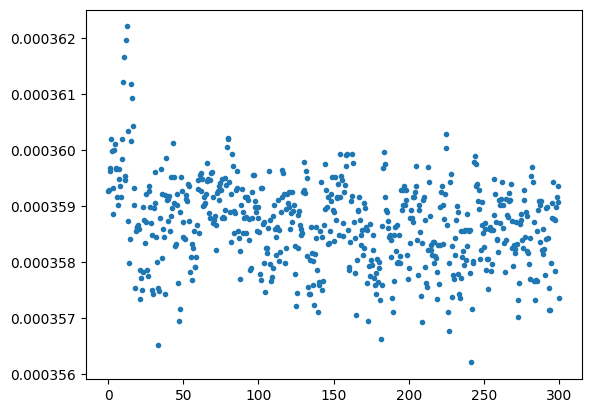

In [38]:
plt.plot(times2, power3, '.')
plt.show()

Text(0, 0.5, 'Attenuation (dB)')

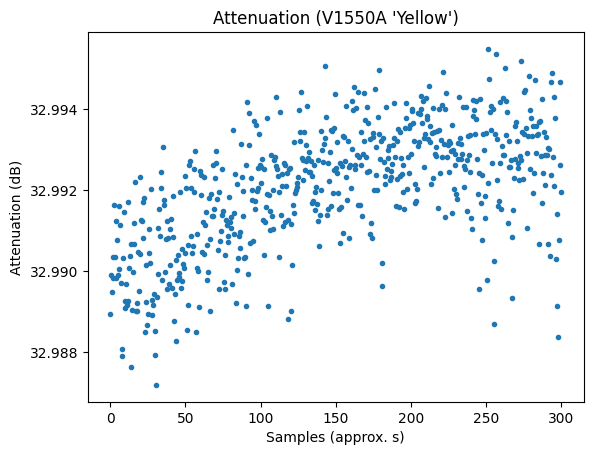

In [45]:
plt.plot(times2, power, '.')
plt.title('Attenuation (V1550A \'Yellow\')')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation (dB)')
#Voltage VOA2 attenuation with 6.0 laser power ???

Text(0, 0.5, 'Power (mW)')

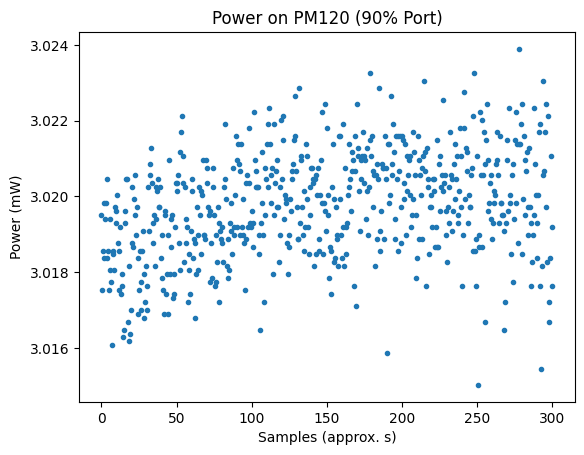

In [43]:
plt.plot(times2, np.multiply(power2,1000), '.')
plt.title('Power on PM120 (90% Port)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')
#Voltage VOA2 attenuation with 6.0 laser power ???

Text(0, 0.5, 'Power (mW)')

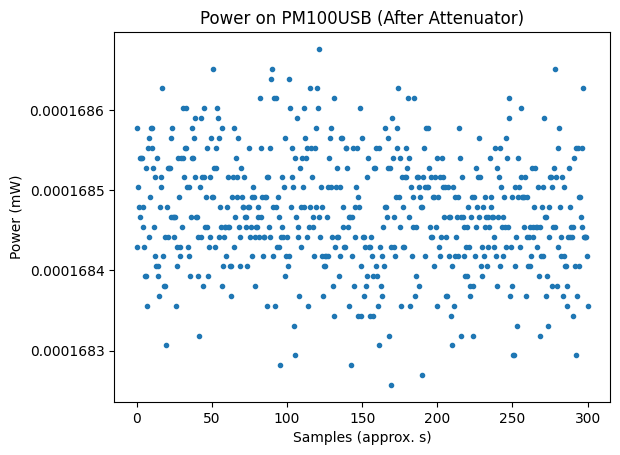

In [44]:
plt.plot(times2, np.multiply(power3, 1000), '.')
plt.title('Power on PM100USB (After Attenuator)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')
#Voltage VOA2 attenuation with 6.0 laser power ???

Second attenuator ('Blue')

In [46]:
# Quick check to measure attenuation

import time

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((0.1/0.9*p5)/p2)
pinv = 10*np.log10((0.9/0.1*p2)/p5)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}")
sys.stdout.flush()
time.sleep(0.5)

 Power on PM100USB after attenuator is:3.33304562e-09
Power on PM120 after 90% beamsplitter port is:0.00301961461
Attenuation is:50.028677505722015

In [49]:
time.perf_counter()

4471.2155174

305.0557872999998


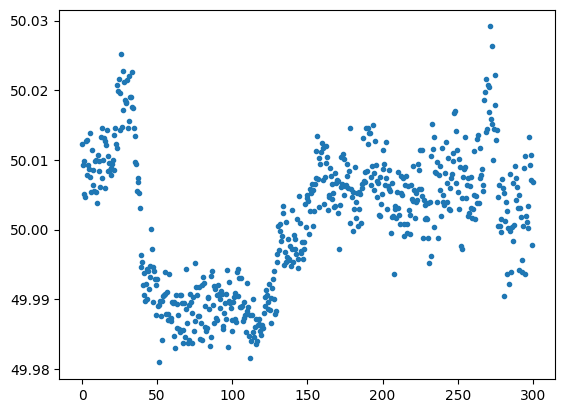

In [50]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

start = time.perf_counter()
for i in range (601):
    t=i*0.5
    p1= pm120.power() # laser 
    p2 = powermeter.power() # attenuator output 
    p = 10*np.log10((0.1/0.9*p1)/p2) # attenuation 
    times2.append(t)
    power2.append(p1)
    power3.append(p2) 
    power.append(p) # attenuation 
    time.sleep(0.5)

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

305.0776119000002


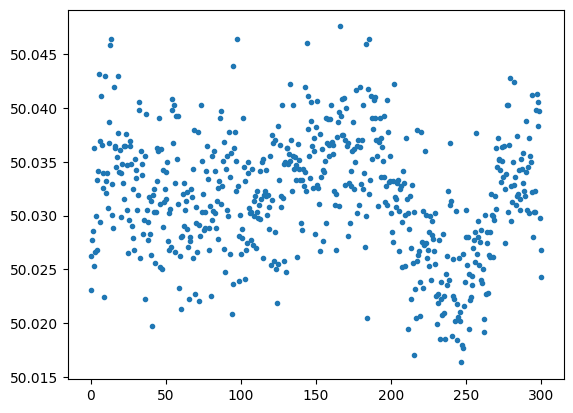

In [51]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

start = time.perf_counter()
for i in range (601):
    t=i*0.5
    p1= pm120.power() # laser 
    p2 = powermeter.power() # attenuator output 
    p = 10*np.log10((0.1/0.9*p1)/p2) # attenuation 
    times2.append(t)
    power2.append(p1)
    power3.append(p2) 
    power.append(p) # attenuation 
    time.sleep(0.5)

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

Text(0, 0.5, 'Attenuation (dB)')

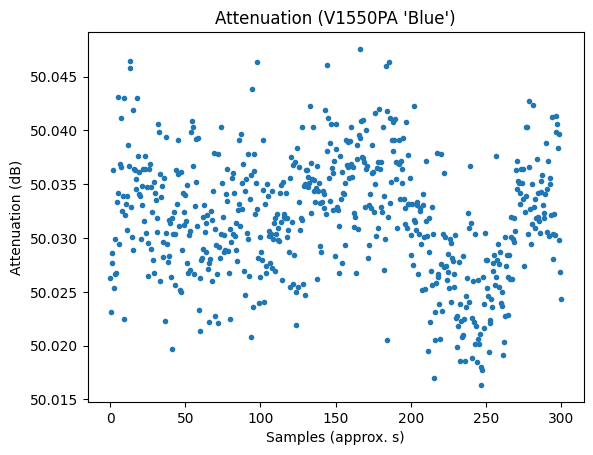

In [55]:
plt.plot(times2, power, '.')
plt.title('Attenuation (V1550PA \'Blue\')')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation (dB)')
#Voltage VOA2 attenuation with 6.0 laser power ???

Text(0, 0.5, 'Power (mW)')

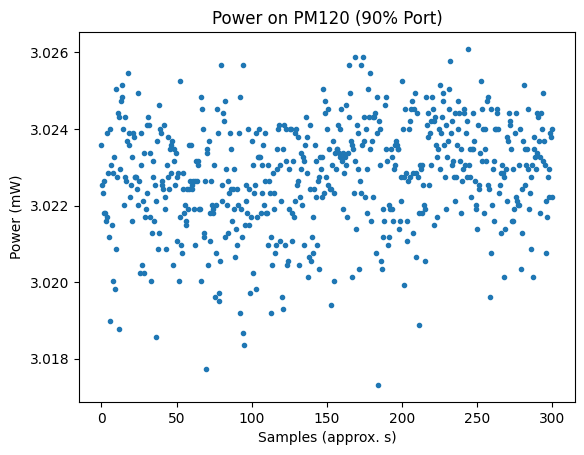

In [53]:
plt.plot(times2, np.multiply(power2,1000), '.')
plt.title('Power on PM120 (90% Port)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')
#Voltage VOA2 attenuation with 6.0 laser power ???

Text(0, 0.5, 'Power (mW)')

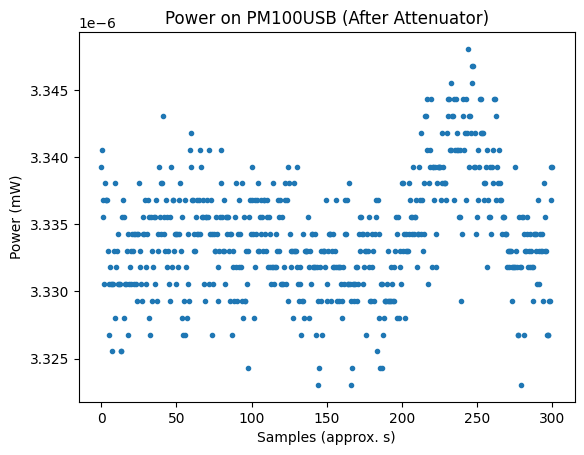

In [54]:
plt.plot(times2, np.multiply(power3, 1000), '.')
plt.title('Power on PM100USB (After Attenuator)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')
#Voltage VOA2 attenuation with 6.0 laser power ???

Dark Counts code

In [90]:
# Oscilloscope count function using search
#self.add_parameter(name="search_total", 
#                           label= "search crossings",
#                           get_cmd="SEARCH:SEARCH1:TOTal?",
#                          unit="counts",)

def count_rate(MS,bin, total):
    MS.clear_search()
    MS.write("TRIGger:A:LEVel:CH1 1")
    start = time.time()
    end = start + total
    last =  int(MS.search_total())

    times = []
    counts= []

    while time.time() < end:
        time.sleep(bin)
        now = time.time()
        count =  int(MS.search_total())
        delta = count 
        counts.append(delta)
        end1 = sum(counts)
    return counts, end1

counts = []
times, counts = count_rate(
    MS = MS, 
    bin = 1, 
    total = 10.01,
)

NameError: name 'MS' is not defined

Initialise database 

In [42]:
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
initialise_or_create_database_at("2026-02_laser_calibration.db")

from time import sleep, monotonic

# Set up experiment
exp_name = 'Laser_calibration_26_02_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Started new experiment


In [65]:
from qcodes.dataset import Measurement
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name

In [ ]:
# n = Counter("n")

# t = np.linspace(1, 10, 10) # Jaime: line added from earlier cell, is this the right t? 

# meas = Measurement()
# meas.register_custom_parameter("n", label="points")
# meas.register_parameter(yoko.current)
# meas.register_parameter(dmm.volt)
# meas.register_custom_parameter("T_MXC", label="mK")

# with meas.run() as datasaver:
#     print(datasaver.run_id)
#     for i in t:
#         datasaver.add_result(("n", n()),
#                              ("T_MXC", tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3),
#                             (dmm.volt, dmm.volt()),
#                             (yoko.current, yoko.current()))
#         time.sleep(0.1)

In [66]:
meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")
t = [1]
with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in t:
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((0.1/0.9*p1)/p2) # attenuation 
        datasaver.add_result(("times",t),
                             ("p1", p1),
                            ("p2", p2),
                            ("attenuation", p))
        time.sleep(0.1)

Starting experimental run with id: 2. 
2


In [75]:
data = load_by_id(2).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']

Text(0, 0.5, 'Power (mW)')

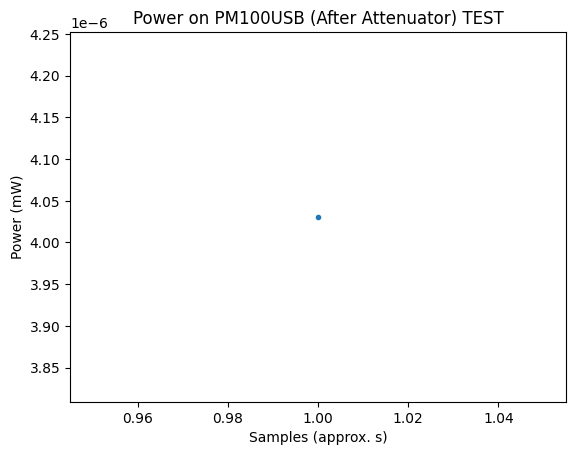

In [76]:
plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator) TEST')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')
#Voltage VOA2 attenuation with 6.0 laser power ???

Checking attenuators 26/2 3pm

Open attenuator VOA. Measuring inside fridge, fibre 1. 

In [46]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [50]:
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True


In [51]:
# Quick check to measure attenuation

import time

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((0.1/0.9*p5)/p2)
pinv = 10*np.log10((0.9/0.1*p2)/p5)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

 Power on PM100USB after attenuator is:0.000353848765
Power on PM120 after 90% beamsplitter port is:0.00480549876
Attenuation is:1.7867827591040366
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 1. 
1
307.7405574000004


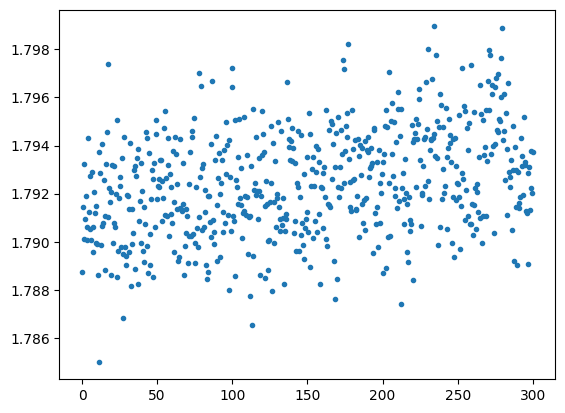

Laser enable status: False


In [53]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((0.1/0.9*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Text(0, 0.5, 'Attenuation dB')

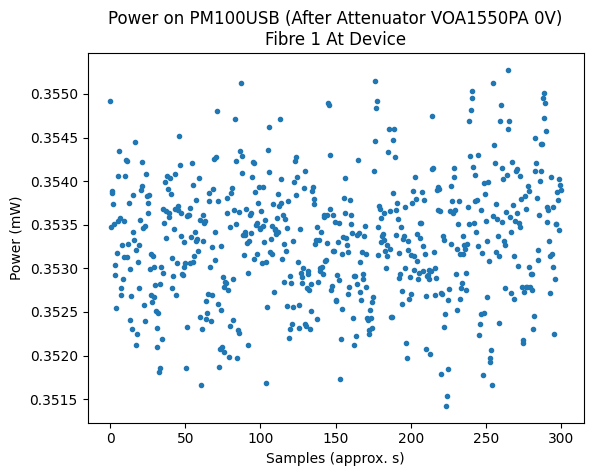

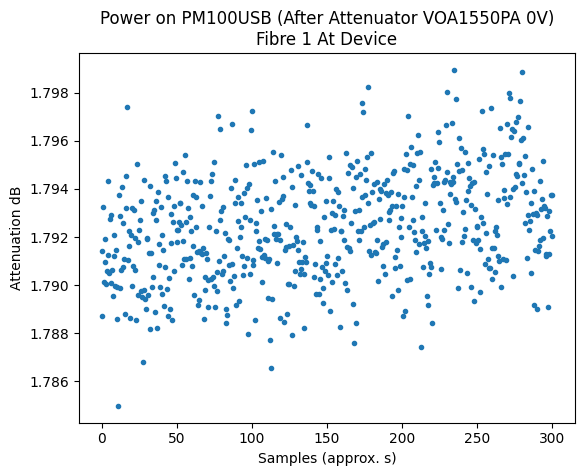

In [56]:
data = load_by_id(1).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']

plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V)\nFibre 1 At Device')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V)\nFibre 1 At Device')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

In [61]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Cleaned fibre connected to fridge port and repeating measurement. 

In [60]:
# Quick check to measure attenuation

import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((0.1/0.9*p5)/p2)
pinv = 10*np.log10((0.9/0.1*p2)/p5)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000265115319
Power on PM120 after 90% beamsplitter port is:0.00479713315
Attenuation is:3.0330444050484933
Laser enable status: False


In [62]:
# Quick check to measure attenuation

import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((0.1/0.9*p5)/p2)
pinv = 10*np.log10((0.9/0.1*p2)/p5)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000265042152
Power on PM120 after 90% beamsplitter port is:0.00480549876
Attenuation is:3.0418101095707364
Laser enable status: False


In [63]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Measured value is very different to what it was before. Swapping to fibre 2. 

In [64]:
# Quick check to measure attenuation

import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((0.1/0.9*p5)/p2)
pinv = 10*np.log10((0.9/0.1*p2)/p5)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.00032086487
Power on PM120 after 90% beamsplitter port is:0.00479399599
Attenuation is:2.2013298616879675
Laser enable status: False


In [65]:
# Quick check to measure attenuation

import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((0.1/0.9*p5)/p2)
pinv = 10*np.log10((0.9/0.1*p2)/p5)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000320243009
Power on PM120 after 90% beamsplitter port is:0.00478563132
Attenuation is:2.2021707079432757
Laser enable status: False


In [67]:
# Quick check to measure attenuation

import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((0.1/0.9*p5)/p2)
pinv = 10*np.log10((0.9/0.1*p2)/p5)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000319243089
Power on PM120 after 90% beamsplitter port is:0.00478563132
Attenuation is:2.2157522414157453
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 2. 
2
307.55511900000056


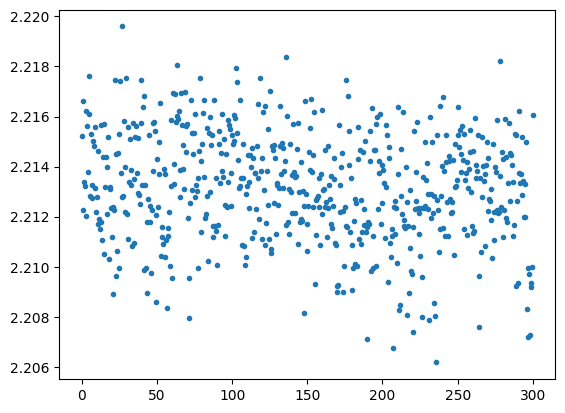

Laser enable status: False


Text(0, 0.5, 'Attenuation dB')

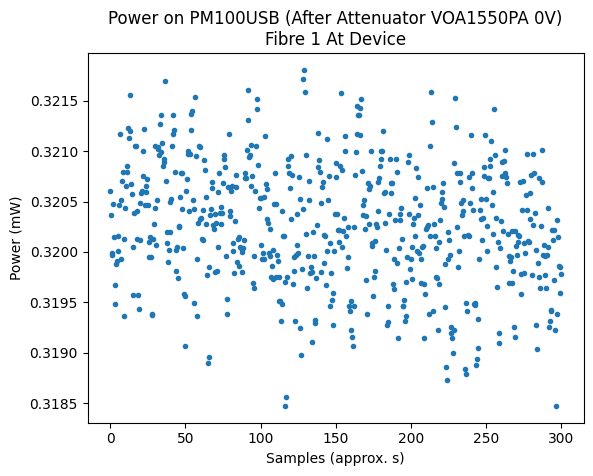

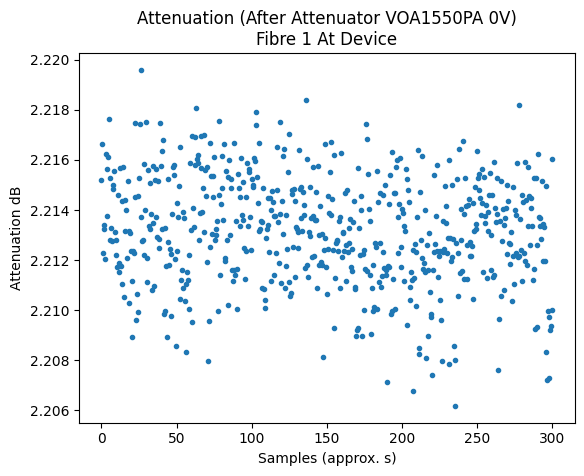

In [68]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((0.1/0.9*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')


data = load_by_id(datasaver.run_id).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']

plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V)\nFibre 1 At Device')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V)\nFibre 1 At Device')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

Text(0, 0.5, 'Attenuation dB')

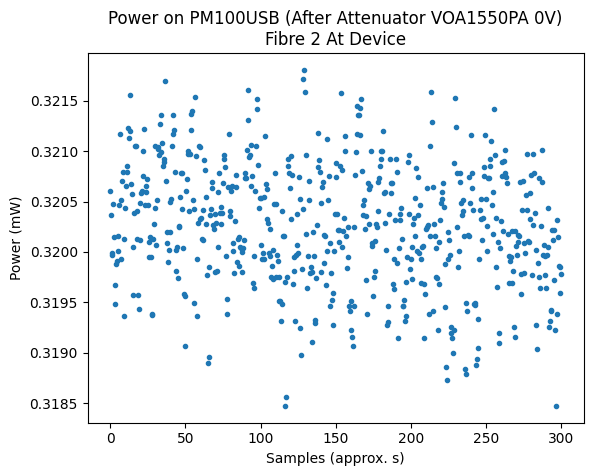

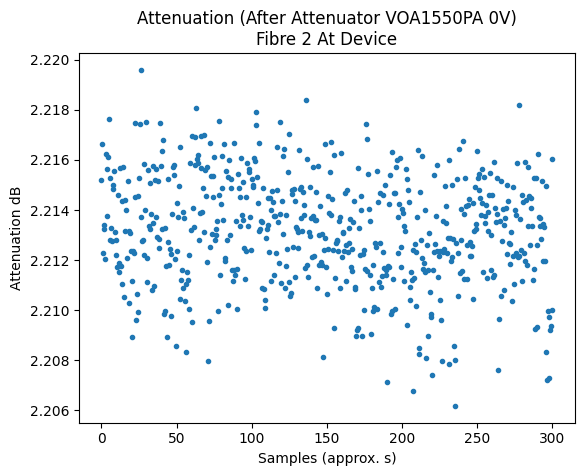

In [69]:
plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V)\nFibre 2 At Device')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V)\nFibre 2 At Device')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

In [71]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


2/3/26
- Fibre with ends intact through whole fridge fibre port 1  
- Fibre with ends intact through whole fridge fibre port 2  
- Device fibre power meter through whole fridge fibre port 1
- Device fibre power meter through whole fridge fibre port 2
- To fridge entry

Note: for all these measurements, there was no power applied to VOA1550PA. 
- Try applying power but 0V to VOA1550PA 

- Fibre with ends intact through whole fridge fibre port 1

In [74]:
powermeter.power()

3.75413763e-12

In [75]:
pm120.power()

1.83831422e-10

In [76]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [77]:
# Quick check to measure attenuation

import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((0.1/0.9*p5)/p2)
pinv = 10*np.log10((0.9/0.1*p2)/p5)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000363884232
Power on PM120 after 90% beamsplitter port is:0.00478876801
Attenuation is:1.650180519415427
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 3. 
3
307.7659375999938


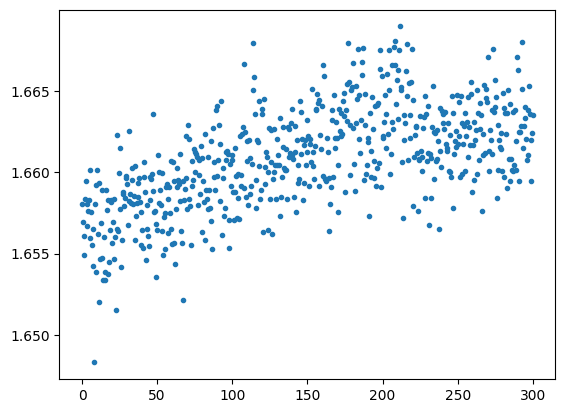

Laser enable status: False


Text(0, 0.5, 'Attenuation dB')

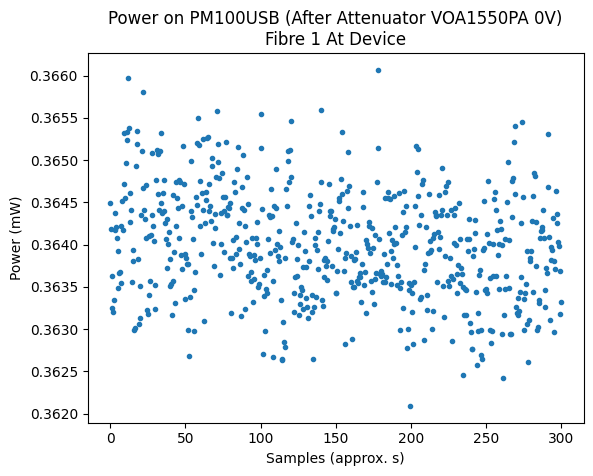

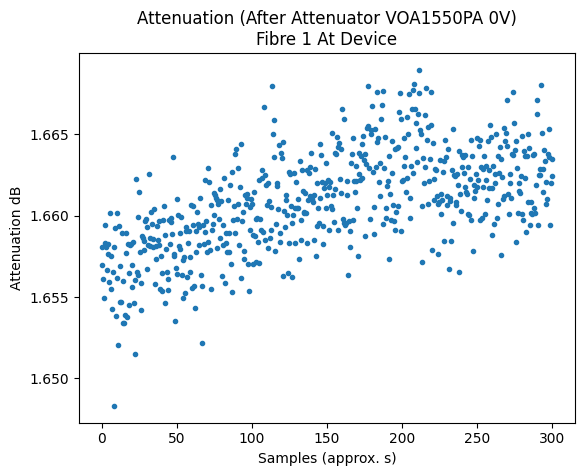

In [78]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((0.1/0.9*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')


data = load_by_id(datasaver.run_id).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']

plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V)\nFibre 1 At Device')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V)\nFibre 1 At Device')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

Text(0, 0.5, 'Attenuation dB')

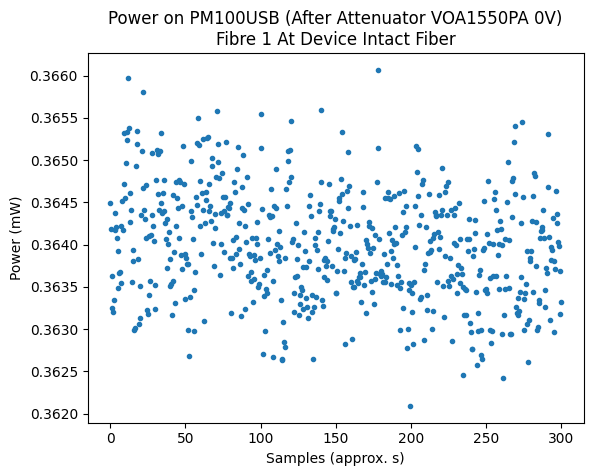

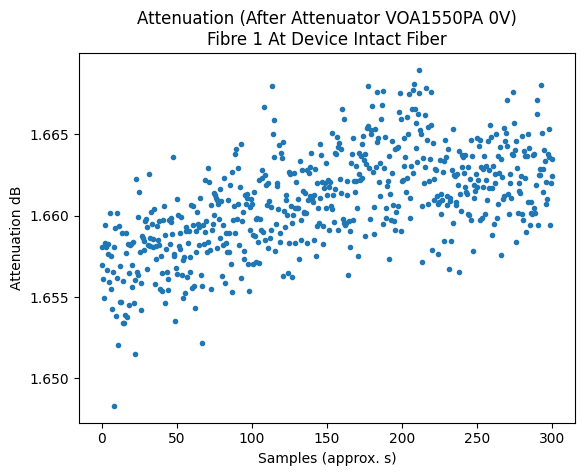

In [79]:
data = load_by_id(datasaver.run_id).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']

plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V)\nFibre 1 At Device Intact Fiber')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V)\nFibre 1 At Device Intact Fiber')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

Same configuration VOA set to 0V applied with output on. Smallest voltgae which can be set is 0.001V. 

In [80]:
# Quick check to measure attenuation

import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((0.1/0.9*p5)/p2)
pinv = 10*np.log10((0.9/0.1*p2)/p5)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000363298896
Power on PM120 after 90% beamsplitter port is:0.00478981389
Attenuation is:1.6581205150755585
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 4. 
4
308.25067639996996


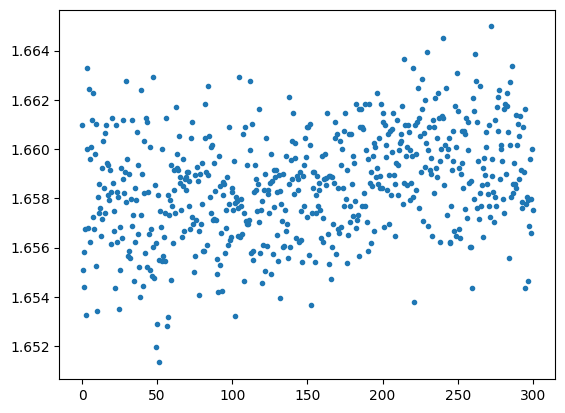

Laser enable status: False


In [81]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((0.1/0.9*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



Text(0, 0.5, 'Attenuation dB')

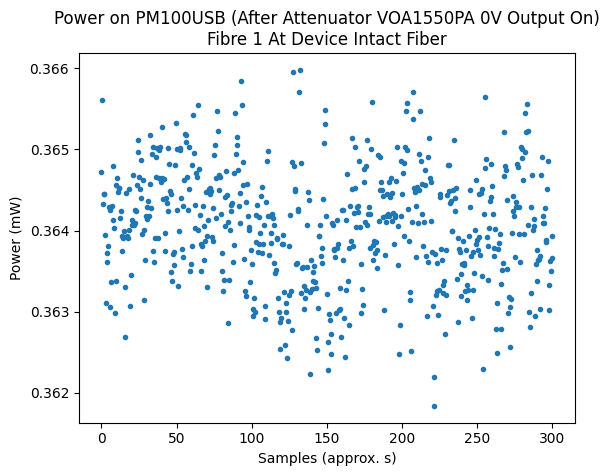

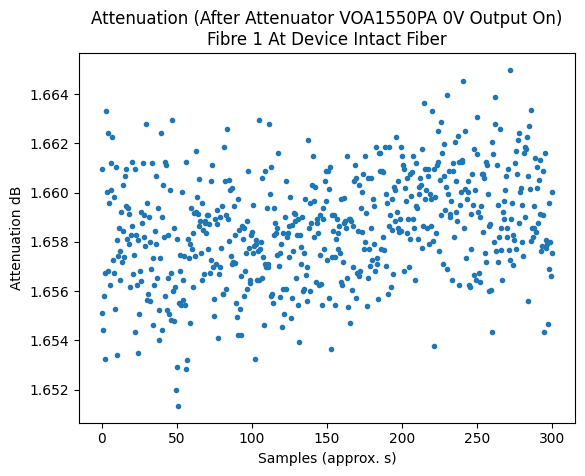

In [82]:
data = load_by_id(datasaver.run_id).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']

plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V Output On)\nFibre 1 At Device Intact Fiber')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V Output On)\nFibre 1 At Device Intact Fiber')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

In [83]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')


Laser enable status: False


Measuring beam splitter again. 10% port to PM100USB. 90% port to PM120

In [84]:
# Quick check to measure attenuation

import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((0.1/0.9*p5)/p2)
pinv = 10*np.log10((0.9/0.1*p2)/p5)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000462067837
Power on PM120 after 90% beamsplitter port is:0.00477726618
Attenuation is:0.6023119078254695
Laser enable status: False


In [85]:
total = 0.000462067837 + 0.00477726618

In [86]:
p2/total # 10% port 

0.08819209378534265

In [87]:
p5/total # 90% port 

0.9118079062146573

Adjusting calculation of attenuation


In [88]:
bs90 = 0.9118079062146573
bs10 = 0.08819209378534265
p = 10*np.log10((bs10/bs90*p5)/p2)

RE-calculating attenuation for ID 4 with new beam splitter ratio

Text(0, 0.5, 'Attenuation dB')

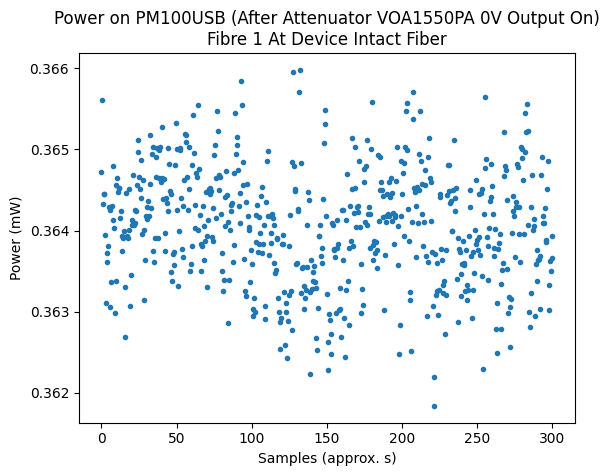

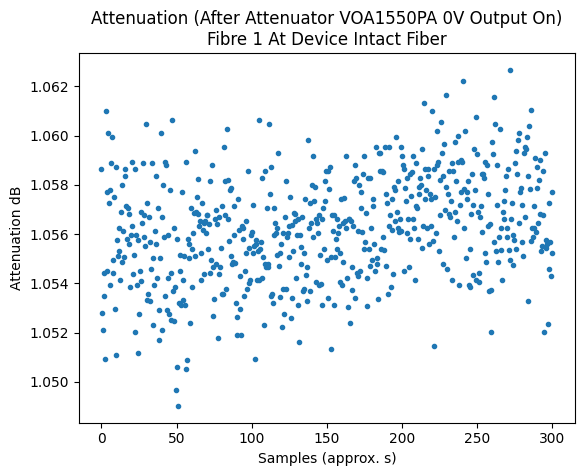

In [90]:
data = load_by_id(4).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265
attenuation = 10*np.log10((bs10/bs90*p1_before_att)/p2_after_att)



plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V Output On)\nFibre 1 At Device Intact Fiber')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V Output On)\nFibre 1 At Device Intact Fiber')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

In [94]:

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Fibre with ends intact through whole fridge fibre port 2 (VOA output on, 0V applied)

In [95]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000314682635
Power on PM120 after 90% beamsplitter port is:0.00480863592
Attenuation is:1.6967541793601895
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 5. 
5
307.5108940000064


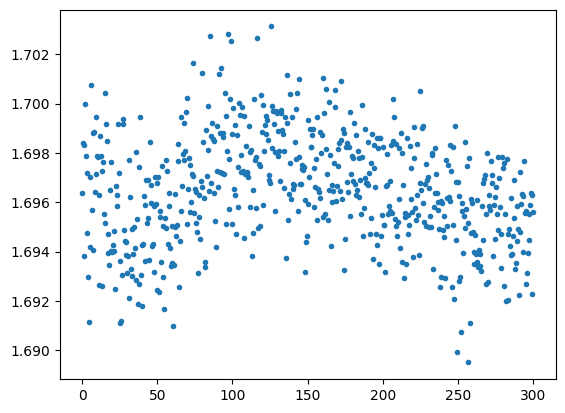

Laser enable status: False


In [97]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



Text(0, 0.5, 'Attenuation dB')

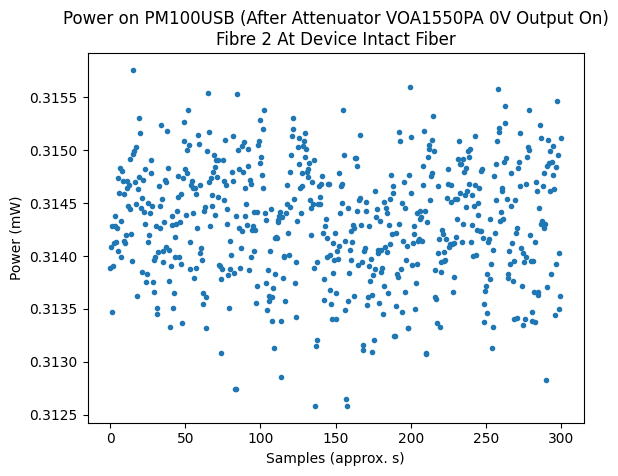

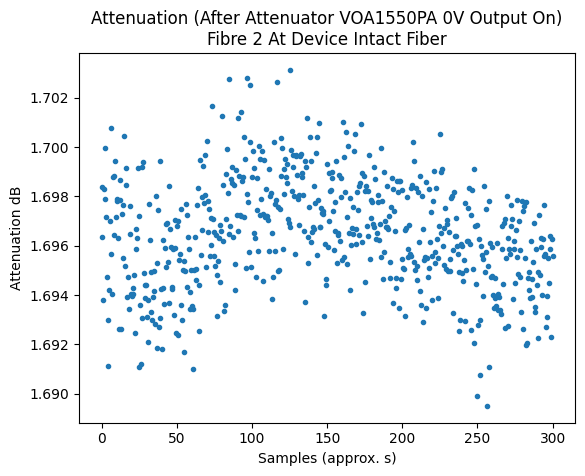

In [98]:
data = load_by_id(5).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']


plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V Output On)\nFibre 2 At Device Intact Fiber')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V Output On)\nFibre 2 At Device Intact Fiber')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

In [100]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


To fridge entry

In [101]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000400770135
Power on PM120 after 90% beamsplitter port is:0.00480549876
Attenuation is:0.6436941843751309
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 6. 
6
307.793276100012


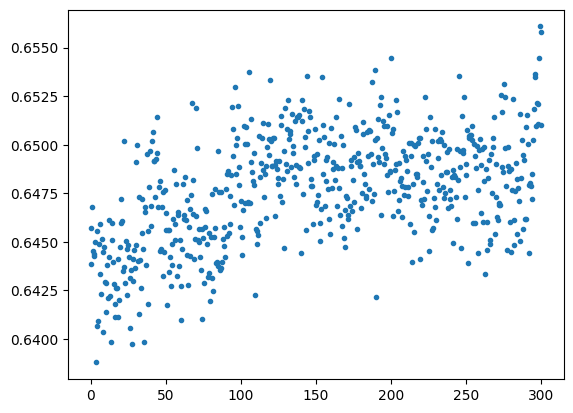

Laser enable status: False


In [102]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



Text(0, 0.5, 'Attenuation dB')

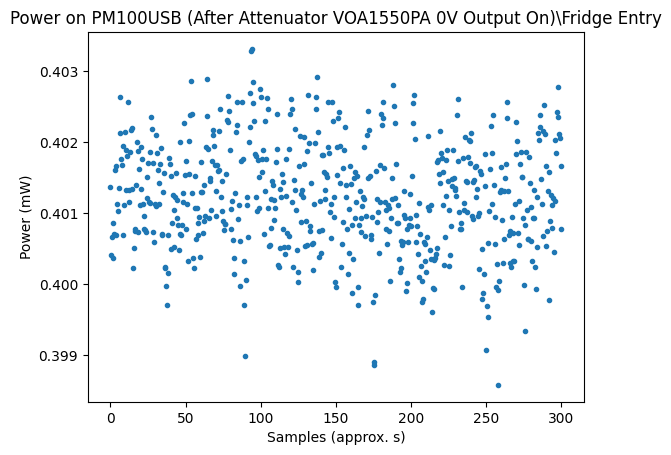

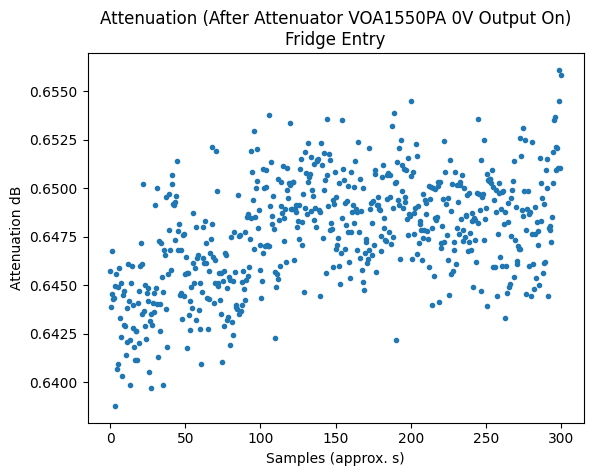

In [103]:
data = load_by_id(6).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']


plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V Output On)\Fridge Entry')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V Output On)\nFridge Entry')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

In [104]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Repeating Fibre 1 with intact fibre connection

In [105]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000354190241
Power on PM120 after 90% beamsplitter port is:0.00481700059
Attenuation is:1.1906640837860138
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 7. 
7
307.5669478000491


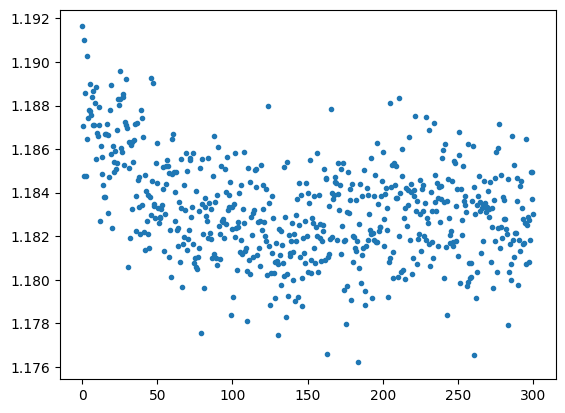

Laser enable status: False


In [106]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



In [109]:

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



Laser enable status: False


Text(0, 0.5, 'Attenuation dB')

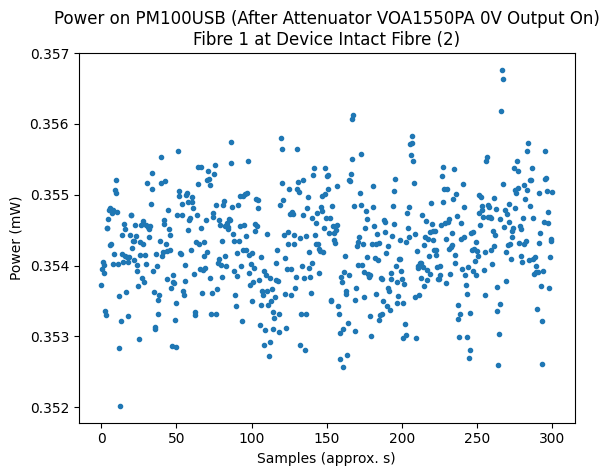

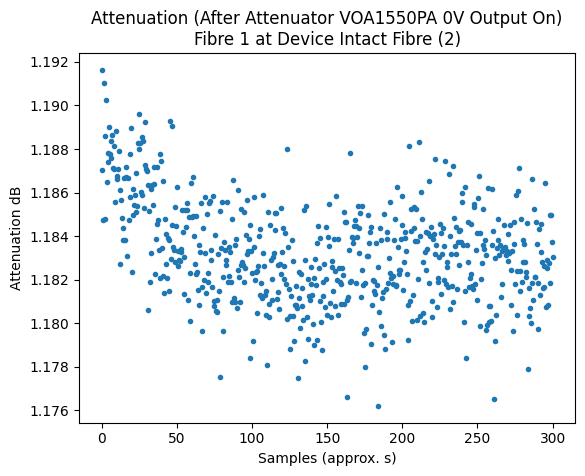

In [110]:
data = load_by_id(7).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']


plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V Output On)\nFibre 1 at Device Intact Fibre (2)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V Output On)\nFibre 1 at Device Intact Fibre (2)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

Repeating Fibre 2 with intact fibre connection

In [111]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.00033631429
Power on PM120 after 90% beamsplitter port is:0.00480968133
Attenuation is:1.408972816254661
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 8. 
8
308.0532352000009


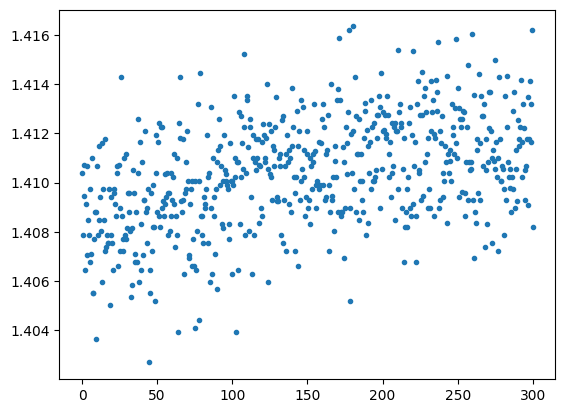

Laser enable status: False


In [112]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



Text(0, 0.5, 'Attenuation dB')

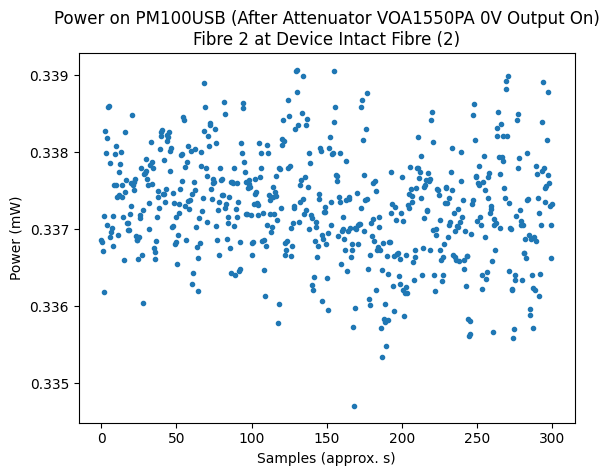

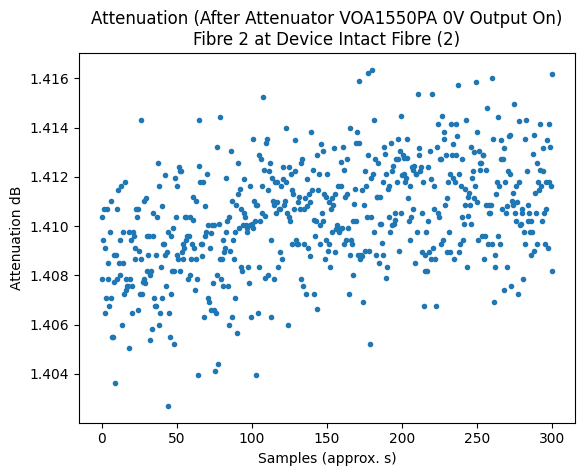

In [115]:
data = load_by_id(8).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']


plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V Output On)\nFibre 2 at Device Intact Fibre (2)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V Output On)\nFibre 2 at Device Intact Fibre (2)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Fridge entry 

In [116]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000406464562
Power on PM120 after 90% beamsplitter port is:0.00480445335
Attenuation is:0.5814759342841939
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 9. 
9
307.7976609999896


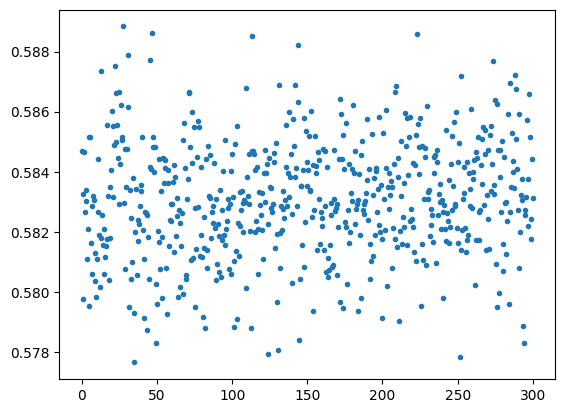

Laser enable status: False


In [117]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



Text(0, 0.5, 'Attenuation dB')

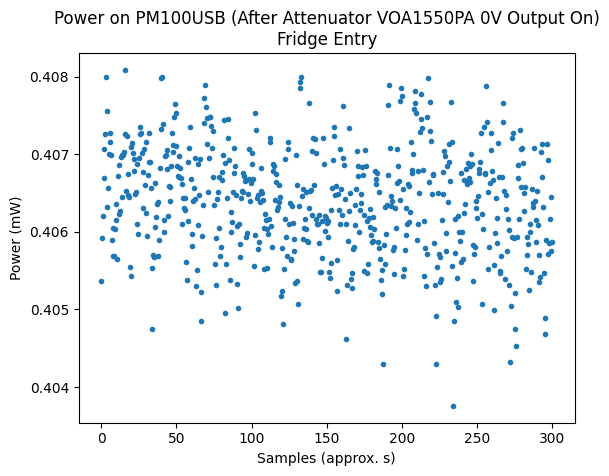

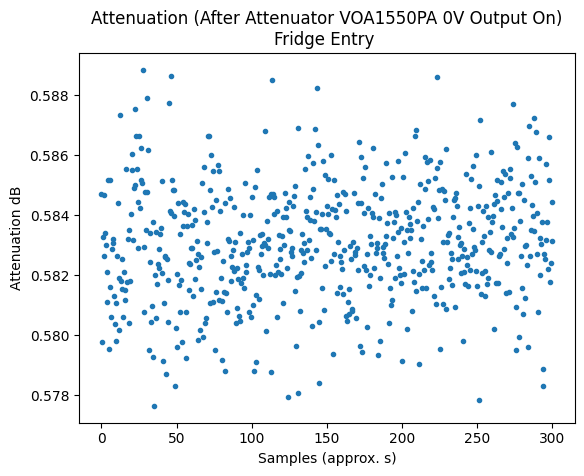

In [118]:
data = load_by_id(9).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']


plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V Output On)\nFridge Entry')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V Output On)\nFridge Entry ')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

In [119]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



Laser enable status: False


Fibre 1 At Device Intact Fibre 

In [120]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.00034888598
Power on PM120 after 90% beamsplitter port is:0.00482013775
Attenuation is:1.2590223181736997
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 10. 
10
307.7416016999632


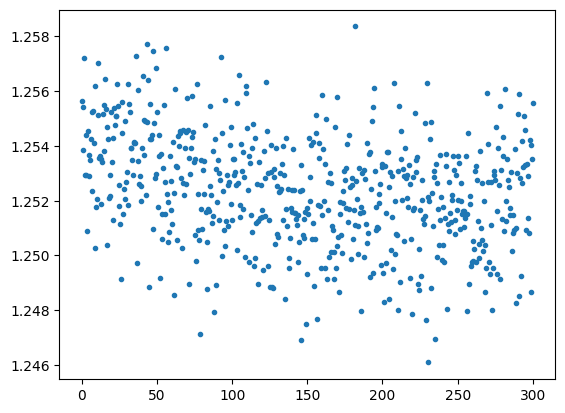

Laser enable status: False


In [121]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



Text(0, 0.5, 'Attenuation dB')

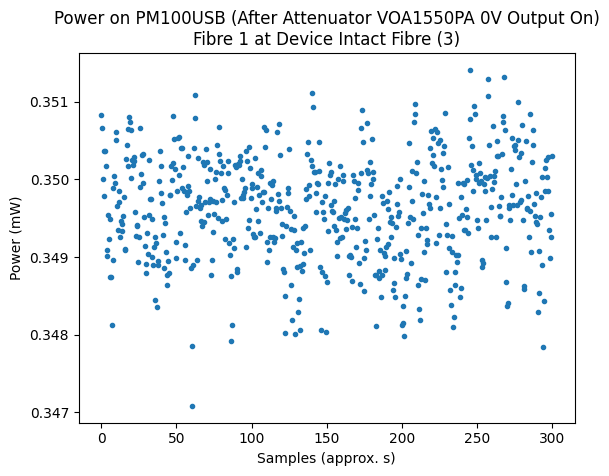

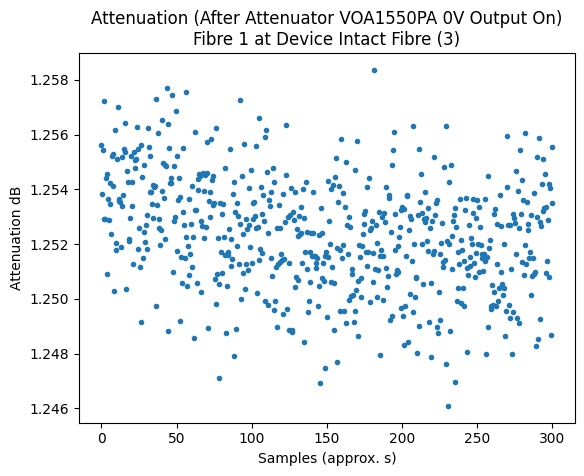

In [127]:
data = load_by_id(10).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']


plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V Output On)\nFibre 1 at Device Intact Fibre (3)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V Output On)\nFibre 1 at Device Intact Fibre (3)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

In [129]:

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



Laser enable status: False


Fibre 2 device intact. 

Fiber cleaning microscope broken, doing a quick sweep anyway. All fiber connections have been cleaned but can't see surface well enough to check. 

In [130]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.00033200992
Power on PM120 after 90% beamsplitter port is:0.00476158084
Attenuation is:1.4212640174526328
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 11. 
11
308.20231510000303


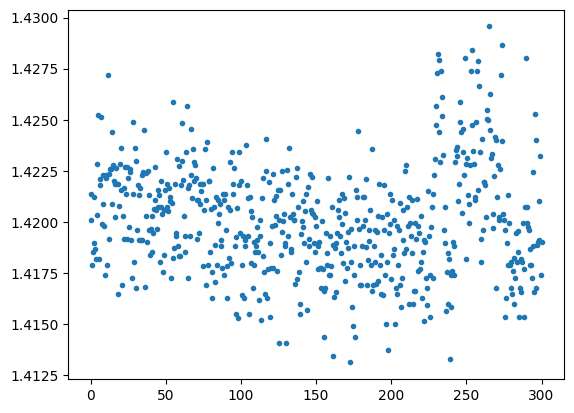

Laser enable status: False


In [131]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



Text(0, 0.5, 'Attenuation dB')

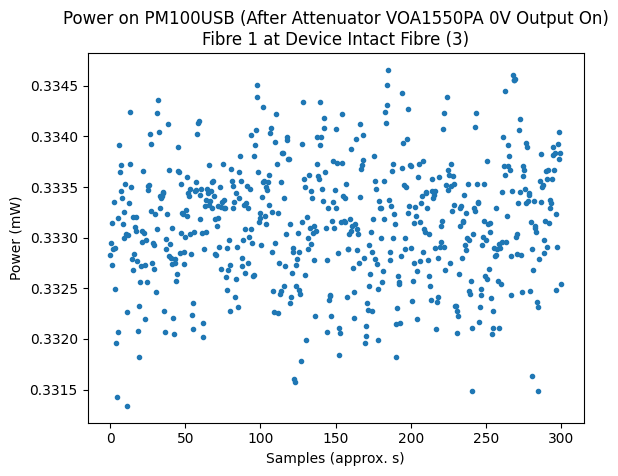

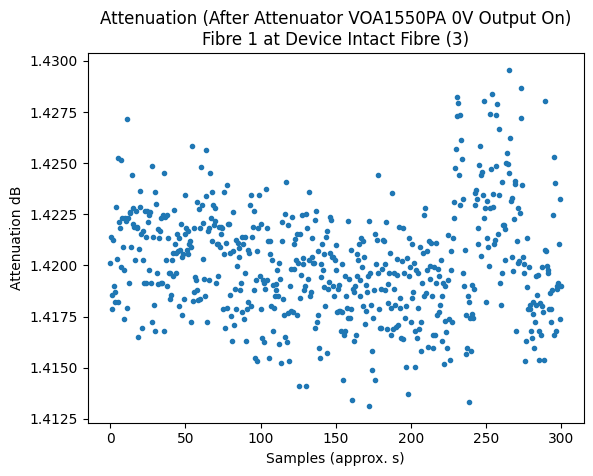

In [132]:
data = load_by_id(11).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']


plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V Output On)\nFibre 1 at Device Intact Fibre (3)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V Output On)\nFibre 1 at Device Intact Fibre (3)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

In [133]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')



Laser enable status: False


Green fiber cap is on the fiber that was on port 2!!!!

TOmorrow: 5V attenuator and knob attenuator 

3/3/26

- Fibre 2 with commercial fibre round 3 
- Fridge entry round 3. 
- 5V on attenuator 
- Knob attenuator 

In [134]:
print(f'Laser enable status: {laser.enable()}')


Laser enable status: False


Fibre 2 with intact connector,. 0V on attenuator output on. Measurement 3. 

Cleaned all fibres prior to taking measurement

In [135]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000304403395
Power on PM120 after 90% beamsplitter port is:0.00481700059
Attenuation is:1.8485350749007787
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 12. 
12
307.69796479999786


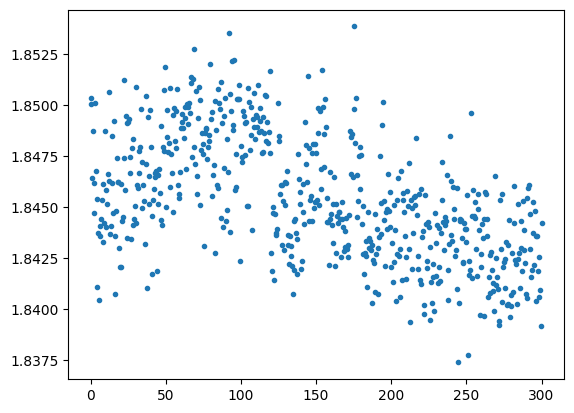

Laser enable status: False


In [136]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Text(0, 0.5, 'Attenuation dB')

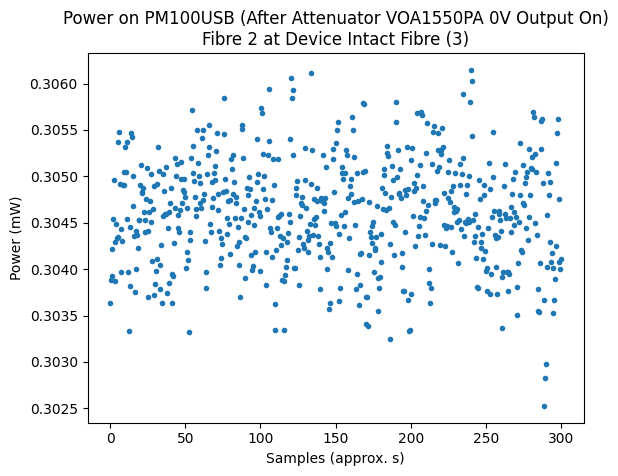

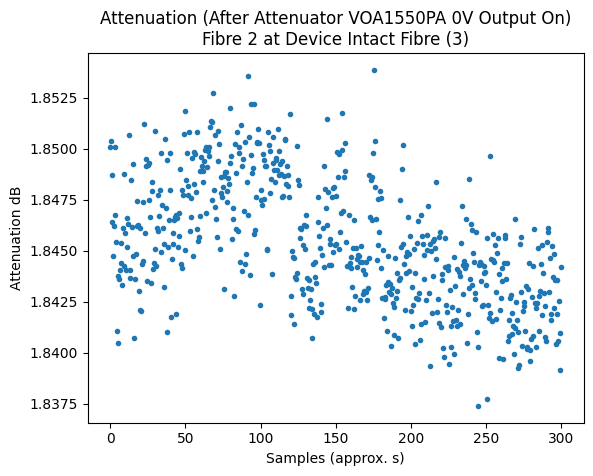

In [138]:
data = load_by_id(12).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']


plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V Output On)\nFibre 2 at Device Intact Fibre (3)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V Output On)\nFibre 2 at Device Intact Fibre (3)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

In [140]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Fridge fiber round 3

In [141]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000406915759
Power on PM120 after 90% beamsplitter port is:0.00481909188
Attenuation is:0.5898699684433917
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 13. 
13
307.35666629998013


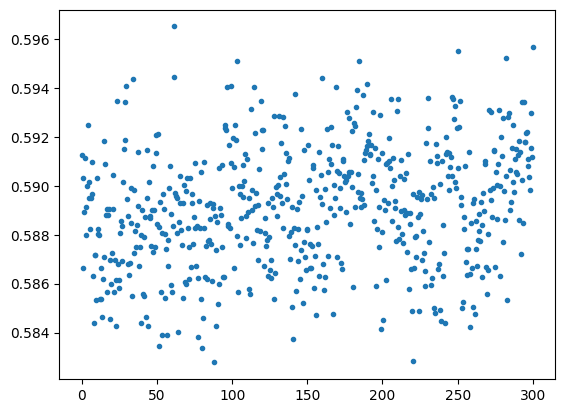

Laser enable status: False


In [142]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Text(0, 0.5, 'Attenuation dB')

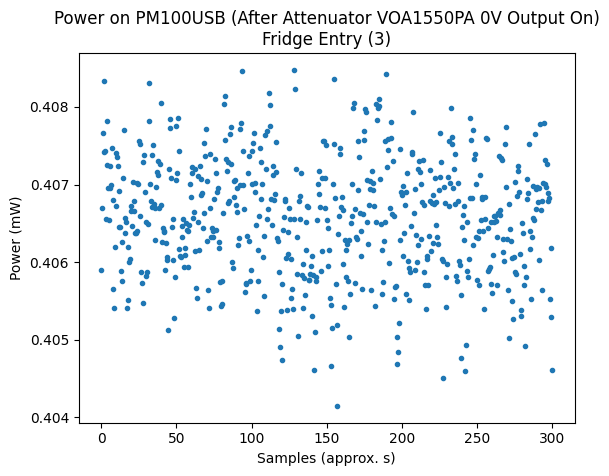

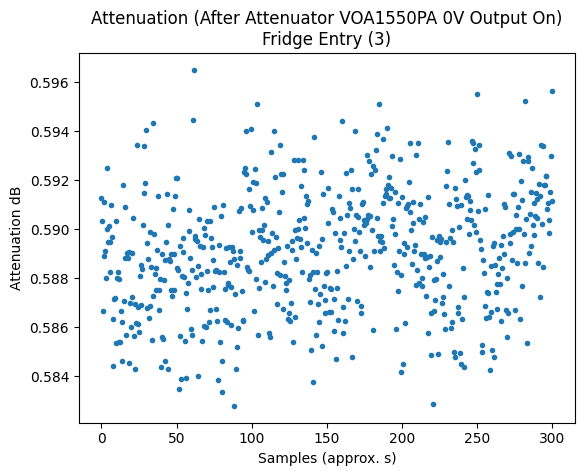

In [144]:
data = load_by_id(13).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']


plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 0V Output On)\nFridge Entry (3)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 0V Output On)\nFridge Entry (3)')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

In [146]:
np.average([1.056, 1.184, 1.252])


np.float64(1.164)

In [147]:
np.average([1.696, 1.410, 1.845 ])

np.float64(1.6503333333333332)

In [148]:
np.average([0.647, 0.583, 0.589 ])

np.float64(0.6063333333333333)

In [149]:
np.average([1.056, 1.184, 1.252])-np.average([0.647, 0.583, 0.589 ])

np.float64(0.5576666666666666)

In [150]:
np.average([1.696, 1.410, 1.845 ])-np.average([0.647, 0.583, 0.589 ])

np.float64(1.044)

In [151]:
f1dB = np.average([1.056, 1.184, 1.252])

In [152]:
10**(f1dB/10)

np.float64(1.3073744701631327)

In [153]:
f2dB = np.average([1.696, 1.410, 1.845 ])

In [154]:
10**(f2dB/10)

np.float64(1.462289405009177)

In [155]:
10**(3/10) # sanity check

1.9952623149688795

In [156]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Fridge fiber end: 5V on attenuator 

In [157]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:6.61232802e-09
Power on PM120 after 90% beamsplitter port is:0.00480445335
Attenuation is:48.468158910034106
Laser enable status: False


Checks out 

Laser enable status: True
Starting experimental run with id: 14. 
14
307.70567769999616


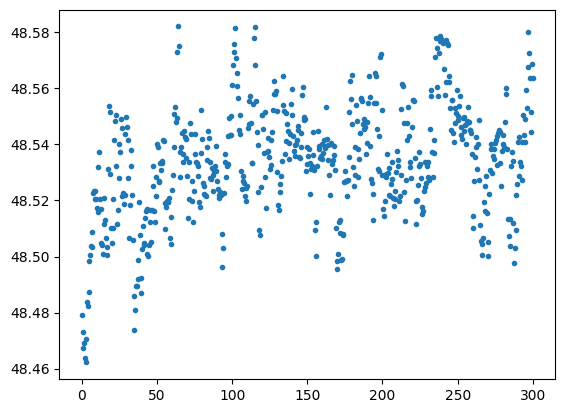

Laser enable status: False


In [158]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Text(0, 0.5, 'Attenuation dB')

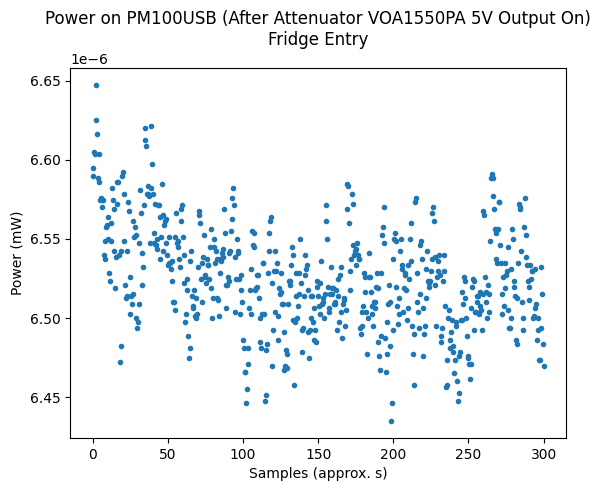

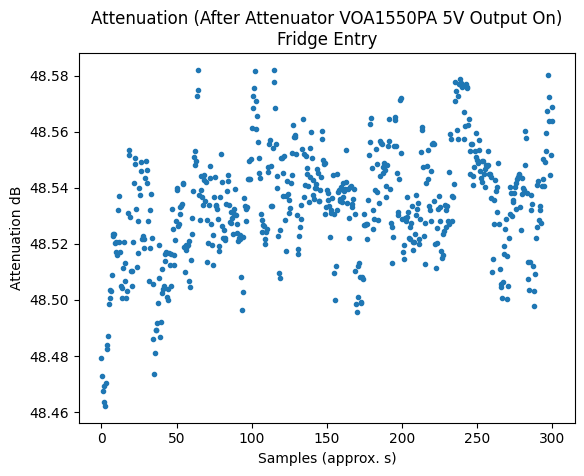

In [160]:
data = load_by_id(14).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']


plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA1550PA 5V Output On)\nFridge Entry')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA1550PA 5V Output On)\nFridge Entry')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

In [161]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Arrange with knob attenuator only

laser -> 10% BS ->  knob attenuator -> fridge fiber -> power measuremnt PM100USB

Knob position unmoved 

In [162]:
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [163]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:6.58232313e-09
Power on PM120 after 90% beamsplitter port is:0.00483582215
Attenuation is:48.51617421700078
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 15. 
15
307.7003983000177


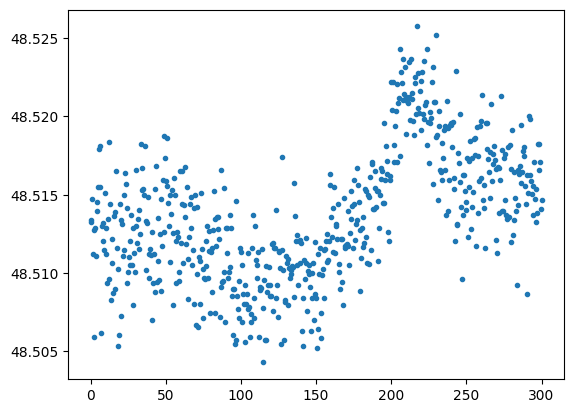

Laser enable status: False


In [164]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Text(0, 0.5, 'Attenuation dB')

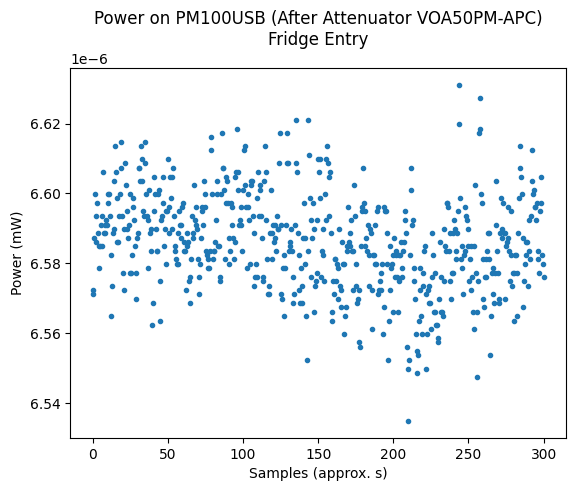

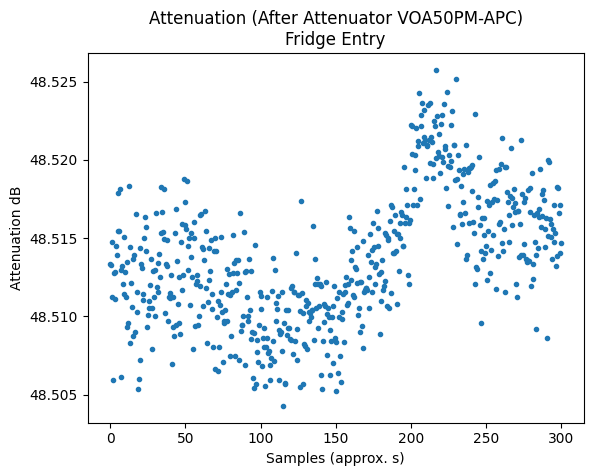

In [165]:
data = load_by_id(15).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']


plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA50PM-APC)\nFridge Entry')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA50PM-APC)\nFridge Entry')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

Bump is weird. Try again 

Laser enable status: True
Starting experimental run with id: 16. 
16
307.43910920002963


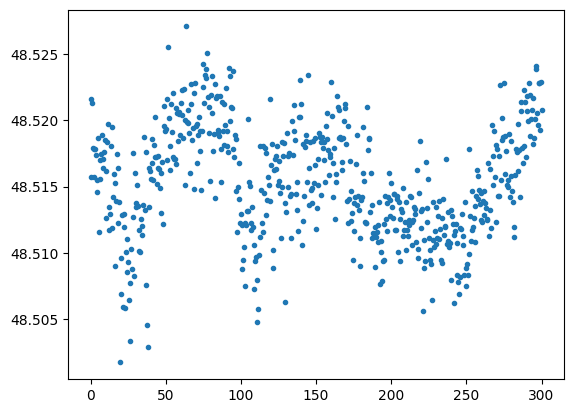

Laser enable status: False


In [166]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Text(0, 0.5, 'Attenuation dB')

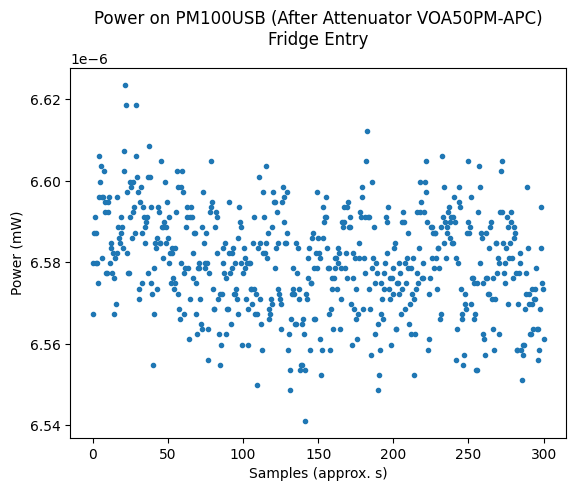

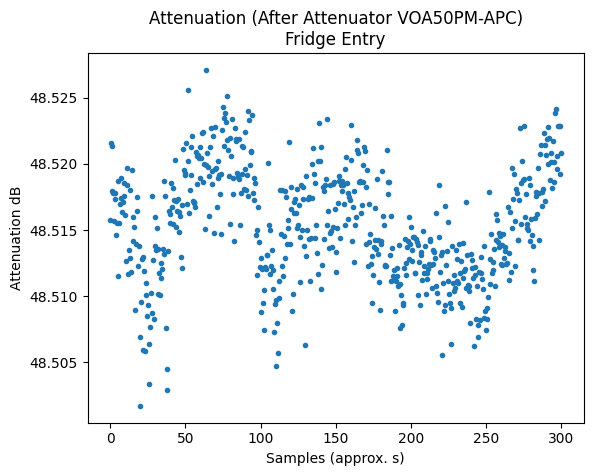

In [167]:
data = load_by_id(16).get_parameter_data()
times = data['times']['times']
p1_before_att = data['p1']['p1']
p2_after_att = data['p2']['p2']
attenuation = data['attenuation']['attenuation']


plt.plot(times, np.multiply(p2_after_att, 1000), '.')
plt.title('Power on PM100USB (After Attenuator VOA50PM-APC)\nFridge Entry')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Power (mW)')


plt.figure()
plt.plot(times, attenuation, '.')
plt.title('Attenuation (After Attenuator VOA50PM-APC)\nFridge Entry')
plt.xlabel('Samples (approx. s)')
plt.ylabel('Attenuation dB')
#Voltage VOA2 attenuation with 6.0 laser power ???

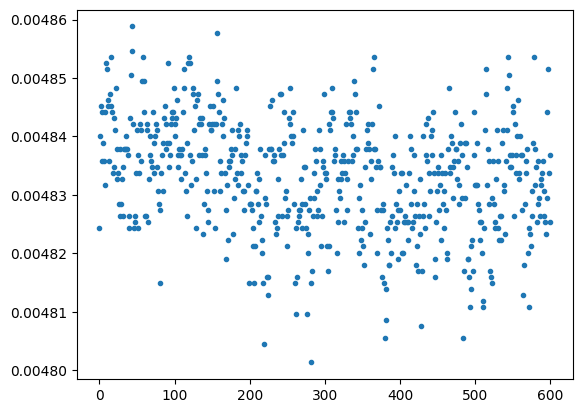

In [170]:
plt.plot(p1_before_att, '.')

In [171]:

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


10% -> knob -> voltage PM 5V -> fridge line -> PM100 SB

In [172]:
laser.enable()

False

In [173]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:2.50450984e-12
Power on PM120 after 90% beamsplitter port is:0.00479190517
Attenuation is:82.67311772386162
Laser enable status: False


In [174]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:1.25400634e-12
Power on PM120 after 90% beamsplitter port is:0.00477622077
Attenuation is:85.66310960438864
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 17. 
17


C:\Users\QNL\AppData\Local\Temp\ipykernel_18288\433495382.py:30: RuntimeWarning: invalid value encountered in log10
  p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation


307.83672030002344


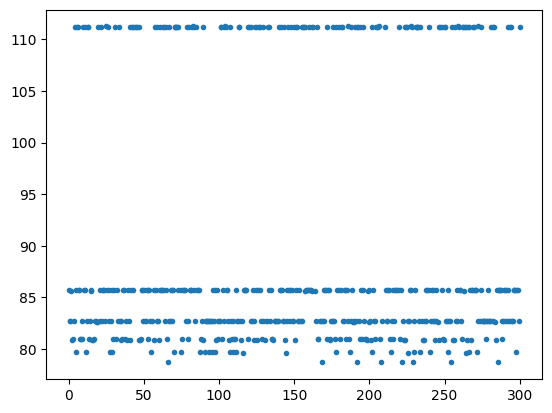

Laser enable status: False


In [175]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Check to see if either has changed - you can't measure them in series!! 

In [181]:

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [188]:
PIndBm = 10*np.log10(4e-3/1e-3)
attenuation = 48 #dB 
PoutdBm = PIndBm - attenuation - attenuation

In [189]:
Pout = 10**(PoutdBm/10)

In [190]:
Pout # 1 nW  

np.float64(1.0047545726038332e-09)

In [191]:
p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)


 Power on PM100USB after attenuator is:9.10152009e-10
Power on PM120 after 90% beamsplitter port is:1.83831422e-10
Attenuation is:-17.091678856451832


In [192]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000294880097
Power on PM120 after 90% beamsplitter port is:0.00483163958
Attenuation is:1.999753693219293
Laser enable status: False


In [193]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000294306985
Power on PM120 after 90% beamsplitter port is:0.00482013775
Attenuation is:1.9978517982515809
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 18. 
18
307.9964478999609


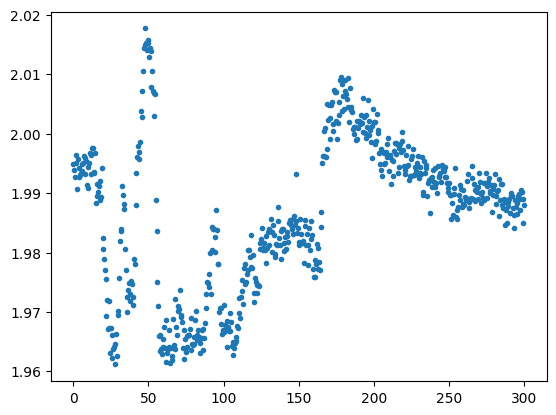

Laser enable status: False


In [194]:
# Run a test to measure attenuation as a function of time
# With polarisation paddle

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (601):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

In [197]:
import time

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

p2 = powermeter.power()
p5 = pm120.power()
p = 10*np.log10((bs10/bs90*p5)/p2)
sys.stdout.write(f"\r Power on PM100USB after attenuator is:{p2}\nPower on PM120 after 90% beamsplitter port is:{p5}\nAttenuation is:{p}\n")
sys.stdout.flush()
time.sleep(2)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
 Power on PM100USB after attenuator is:0.000291417062
Power on PM120 after 90% beamsplitter port is:0.0047908593
Attenuation is:2.01424740856555
Laser enable status: False


Laser enable status: True
Starting experimental run with id: 19. 
19
52.51897530001588


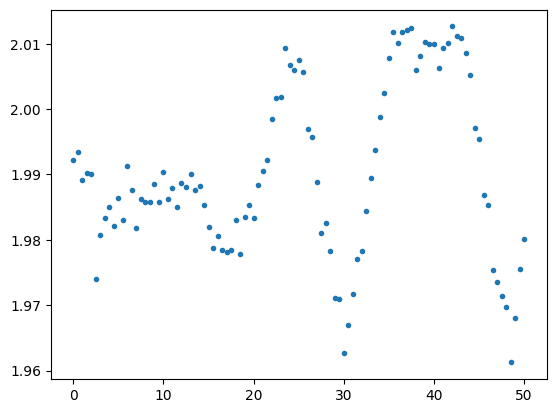

Laser enable status: False


In [198]:
# Run a test to measure attenuation as a function of time

times2 = []
power2 = []
power3 = []
power = []

meas = Measurement()
meas.register_custom_parameter("times", label="Samples (approx. s)")
meas.register_custom_parameter("p2", label="W")
meas.register_custom_parameter("p1", label="W")
meas.register_custom_parameter("attenuation", label="dB")

bs90 = 0.9118079062146573
bs10 = 0.08819209378534265

laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

time.sleep(10)

start = time.perf_counter()

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in range (101):
        t=i*0.5
        p1= pm120.power() # laser 
        p2 = powermeter.power() # attenuator output 
        p = 10*np.log10((bs10/bs90*p1)/p2) # attenuation 
        times2.append(t)
        power2.append(p1)
        power3.append(p2) 
        power.append(p) # attenuation 
        time.sleep(0.5)

        datasaver.add_result(("times",t),
                         ("p1", p1),
                        ("p2", p2),
                        ("attenuation", p))

end = time.perf_counter()
print(end-start)
plt.plot(times2, power, '.')
plt.show()

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

In [199]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


# 9/3/26

Remote setup 

In [202]:
dmm.volt()

-6.10606229e-07

In [203]:
dmm.volt()

0.00113581997

In [215]:
yoko.current(0.005e-3) # set well below transition current 

In [218]:
dmm.volt()

0.00341434829

# 10/3/26

In [219]:
dmm.volt() # I guess this is some offset 

0.00341453888

In [220]:
yoko.current(0.001e-3)

In [221]:
dmm.volt() # I guess this is some offset 

0.000553022559

In [222]:
0.000553022559/0.001e-3

553.022559

In [228]:
current = np.arange(1e-6, 15.5e-6, 0.5e-6)

In [229]:
current

array([1.00e-06, 1.50e-06, 2.00e-06, 2.50e-06, 3.00e-06, 3.50e-06,
       4.00e-06, 4.50e-06, 5.00e-06, 5.50e-06, 6.00e-06, 6.50e-06,
       7.00e-06, 7.50e-06, 8.00e-06, 8.50e-06, 9.00e-06, 9.50e-06,
       1.00e-05, 1.05e-05, 1.10e-05, 1.15e-05, 1.20e-05, 1.25e-05,
       1.30e-05, 1.35e-05, 1.40e-05, 1.45e-05, 1.50e-05])

In [230]:
len(current)

29

In [231]:
current = np.arange(1e-6, 5e-6, 1e-6)

In [232]:
current

array([1.e-06, 2.e-06, 3.e-06, 4.e-06, 5.e-06])

Start current 1e-06
Start current 2e-06
Start current 3e-06
Start current 4e-06
Start current 4.9999999999999996e-06


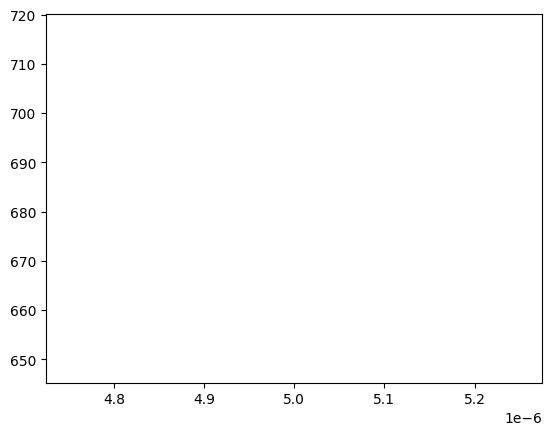

In [235]:
voltage = []
ratio = []
for i in current: 
    
    print(f'Start current {i}')
          
    # set current 
    yoko.current(i)
    
    # wait 
    time.sleep(1)
    
    # measure
    v = dmm.volt()
    frac = v/i
    
    # save 
    voltage.append(v)
    ratio.append(frac)


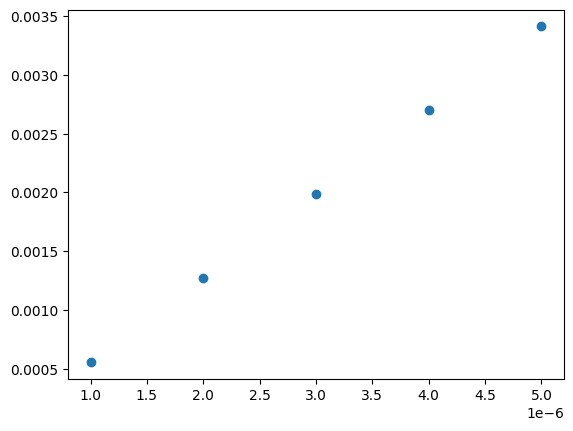

In [239]:
plt.plot(current, voltage, 'o')

In [240]:
yoko.current()

5e-06

In [241]:
current[::-1]

array([5.e-06, 4.e-06, 3.e-06, 2.e-06, 1.e-06])

In [242]:
# ramp down 
print('Ramp down')
for i in current[::-1]: 
    print(f'Current: {i}')
    yoko.current(i)
    time.sleep(1)

Ramp down
Current: 4.9999999999999996e-06
Current: 4e-06
Current: 3e-06
Current: 2e-06
Current: 1e-06


In [243]:
yoko.current()

1e-06

In [244]:
current = np.arange(0.1e-6, 10.5e-6, 0.5e-6)

Start current 1e-07
Start current 6e-07
Start current 1.1e-06
Start current 1.6e-06
Start current 2.1e-06
Start current 2.5999999999999997e-06
Start current 3.1e-06
Start current 3.6e-06
Start current 4.1e-06
Start current 4.6e-06
Start current 5.0999999999999995e-06
Start current 5.6e-06
Start current 6.1e-06
Start current 6.5999999999999995e-06
Start current 7.1e-06
Start current 7.599999999999999e-06
Start current 8.1e-06
Start current 8.6e-06
Start current 9.100000000000001e-06
Start current 9.6e-06
Start current 1.01e-05
Ramp down
Current: 1.01e-05
Current: 9.6e-06
Current: 9.100000000000001e-06
Current: 8.6e-06
Current: 8.1e-06
Current: 7.599999999999999e-06
Current: 7.1e-06
Current: 6.5999999999999995e-06
Current: 6.1e-06
Current: 5.6e-06
Current: 5.0999999999999995e-06
Current: 4.6e-06
Current: 4.1e-06
Current: 3.6e-06
Current: 3.1e-06
Current: 2.5999999999999997e-06
Current: 2.1e-06
Current: 1.6e-06
Current: 1.1e-06
Current: 6e-07
Current: 1e-07


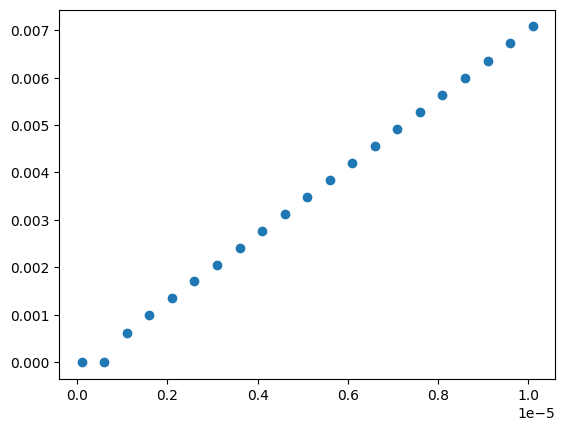

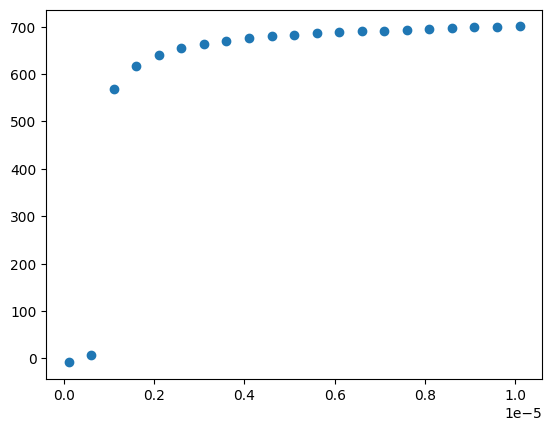

In [245]:
current = np.arange(0.1e-6, 10.5e-6, 0.5e-6)
voltage = []
ratio = []
for i in current: 
    
    print(f'Start current {i}')
          
    # set current 
    yoko.current(i)
    
    # wait 
    time.sleep(1)
    
    # measure
    v = dmm.volt()
    frac = v/i
    
    # save 
    voltage.append(v)
    ratio.append(frac)


print('Ramp down')
for i in current[::-1]: 
    print(f'Current: {i}')
    yoko.current(i)
    time.sleep(1)

plt.plot(current, voltage, 'o')
plt.figure()
plt.plot(current, ratio, 'o')

In [248]:
yoko.current(0)

In [249]:
yoko.current()

0.0

MXC thermometer last measured 7:45pm Monday March 9 at 7mK - should be cold. Critical current must be very low? 

In [269]:
current = np.arange(0.01e-6, 2.03e-6, 0.05e-6)

In [270]:
current

array([1.00e-08, 6.00e-08, 1.10e-07, 1.60e-07, 2.10e-07, 2.60e-07,
       3.10e-07, 3.60e-07, 4.10e-07, 4.60e-07, 5.10e-07, 5.60e-07,
       6.10e-07, 6.60e-07, 7.10e-07, 7.60e-07, 8.10e-07, 8.60e-07,
       9.10e-07, 9.60e-07, 1.01e-06, 1.06e-06, 1.11e-06, 1.16e-06,
       1.21e-06, 1.26e-06, 1.31e-06, 1.36e-06, 1.41e-06, 1.46e-06,
       1.51e-06, 1.56e-06, 1.61e-06, 1.66e-06, 1.71e-06, 1.76e-06,
       1.81e-06, 1.86e-06, 1.91e-06, 1.96e-06, 2.01e-06])

In [271]:
len(current)

41

Start current 1e-08
Start current 6e-08
Start current 1.0999999999999999e-07
Start current 1.6e-07
Start current 2.1e-07
Start current 2.6e-07
Start current 3.1e-07
Start current 3.6e-07
Start current 4.1e-07
Start current 4.6e-07
Start current 5.1e-07
Start current 5.6e-07
Start current 6.1e-07
Start current 6.599999999999999e-07
Start current 7.1e-07
Start current 7.6e-07
Start current 8.1e-07
Start current 8.599999999999999e-07
Start current 9.1e-07
Start current 9.6e-07
Start current 1.0099999999999999e-06
Start current 1.0599999999999998e-06
Start current 1.11e-06
Start current 1.16e-06
Start current 1.2099999999999998e-06
Start current 1.2599999999999998e-06
Start current 1.3099999999999997e-06
Start current 1.36e-06
Start current 1.4099999999999998e-06
Start current 1.4599999999999998e-06
Start current 1.51e-06
Start current 1.5599999999999999e-06
Start current 1.6099999999999998e-06
Start current 1.6599999999999998e-06
Start current 1.7099999999999997e-06
Start current 1.759999

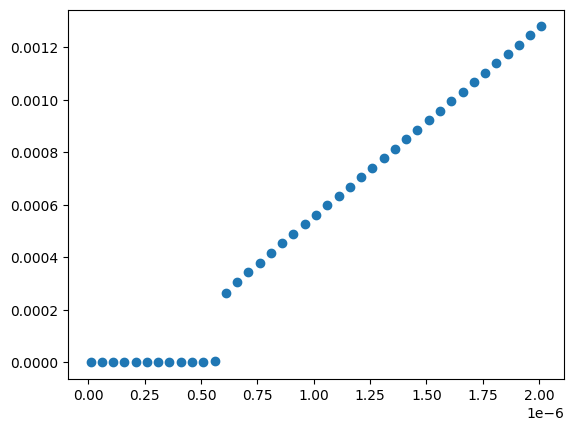

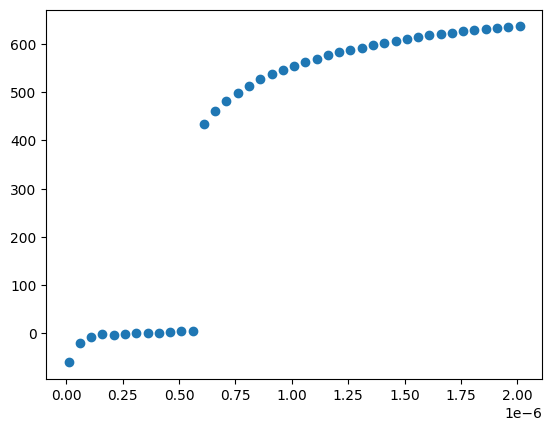

In [272]:
current = np.arange(0.01e-6, 2.03e-6, 0.05e-6)
voltage = []
ratio = []
for i in current: 
    
    print(f'Start current {i}')
          
    # set current 
    yoko.current(i)
    
    # wait 
    time.sleep(1)
    
    # measure
    v = dmm.volt()
    frac = v/i
    
    # save 
    voltage.append(v)
    ratio.append(frac)


print('Ramp down')
for i in current[::-1]: 
    print(f'Current: {i}')
    yoko.current(i)
    time.sleep(1)

plt.plot(current, voltage, 'o')
plt.figure()
plt.plot(current, ratio, 'o')

In [276]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)


currents = np.arange(0.01e-6, 2.03e-6, 0.05e-6)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}'')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Starting experimental run with id: 2. 
2
Ramping down
Current is 1e-08
Finished!


Text(0, 0.5, 'Ratio')

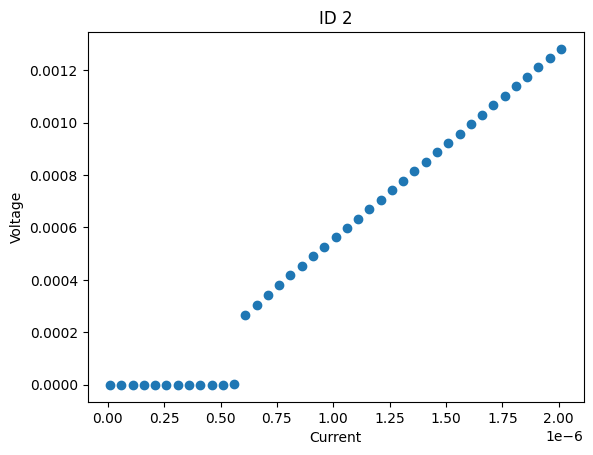

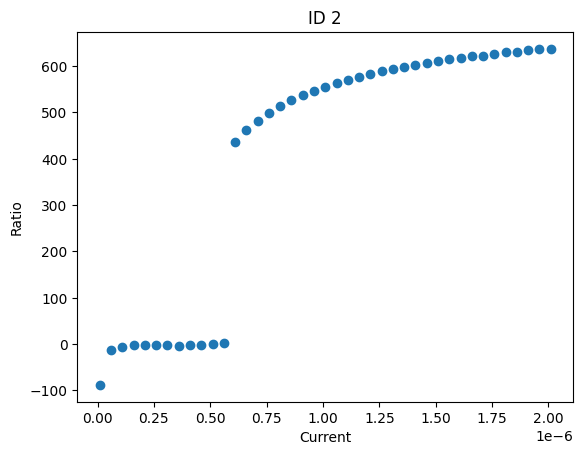

In [278]:
data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']

plt.plot(current, voltage, 'o')
plt.title(f'ID {datasaver.run_id}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {datasaver.run_id}')
plt.xlabel('Current')
plt.ylabel('Ratio')

In [281]:
currents = np.arange(0.5e-6, 11.5e-6, 0.1e-6)

In [282]:
currents

array([5.00e-07, 6.00e-07, 7.00e-07, 8.00e-07, 9.00e-07, 1.00e-06,
       1.10e-06, 1.20e-06, 1.30e-06, 1.40e-06, 1.50e-06, 1.60e-06,
       1.70e-06, 1.80e-06, 1.90e-06, 2.00e-06, 2.10e-06, 2.20e-06,
       2.30e-06, 2.40e-06, 2.50e-06, 2.60e-06, 2.70e-06, 2.80e-06,
       2.90e-06, 3.00e-06, 3.10e-06, 3.20e-06, 3.30e-06, 3.40e-06,
       3.50e-06, 3.60e-06, 3.70e-06, 3.80e-06, 3.90e-06, 4.00e-06,
       4.10e-06, 4.20e-06, 4.30e-06, 4.40e-06, 4.50e-06, 4.60e-06,
       4.70e-06, 4.80e-06, 4.90e-06, 5.00e-06, 5.10e-06, 5.20e-06,
       5.30e-06, 5.40e-06, 5.50e-06, 5.60e-06, 5.70e-06, 5.80e-06,
       5.90e-06, 6.00e-06, 6.10e-06, 6.20e-06, 6.30e-06, 6.40e-06,
       6.50e-06, 6.60e-06, 6.70e-06, 6.80e-06, 6.90e-06, 7.00e-06,
       7.10e-06, 7.20e-06, 7.30e-06, 7.40e-06, 7.50e-06, 7.60e-06,
       7.70e-06, 7.80e-06, 7.90e-06, 8.00e-06, 8.10e-06, 8.20e-06,
       8.30e-06, 8.40e-06, 8.50e-06, 8.60e-06, 8.70e-06, 8.80e-06,
       8.90e-06, 9.00e-06, 9.10e-06, 9.20e-06, 9.30e-06, 9.40e

In [283]:
len(currents)

110

In [284]:
yoko.current()

1e-08

In [286]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)

currents = np.arange(0.5e-6, 13.5e-6, 0.1e-6)


with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Starting experimental run with id: 3. 
3
Start current 5e-07
Start current 6e-07
Start current 7e-07
Start current 8e-07
Start current 9e-07
Start current 1e-06
Start current 1.1e-06
Start current 1.2e-06
Start current 1.2999999999999998e-06
Start current 1.4e-06
Start current 1.5e-06
Start current 1.6e-06
Start current 1.6999999999999998e-06
Start current 1.7999999999999997e-06
Start current 1.9e-06
Start current 2e-06
Start current 2.1e-06
Start current 2.1999999999999997e-06
Start current 2.3e-06
Start current 2.4e-06
Start current 2.4999999999999998e-06
Start current 2.5999999999999997e-06
Start current 2.7e-06
Start current 2.8e-06
Start current 2.8999999999999998e-06
Start current 2.9999999999999997e-06
Start current 3.0999999999999995e-06
Start current 3.2e-06
Start current 3.2999999999999997e-06
Start current 3.3999999999999996e-06
Start current 3.5e-06
Start current 3.6e-06
Start current 3.6999999999999997e-06
Start current 3.7999999999999996e-06
Start current 3.9e-06
Start cu

Text(0, 0.5, 'Ratio')

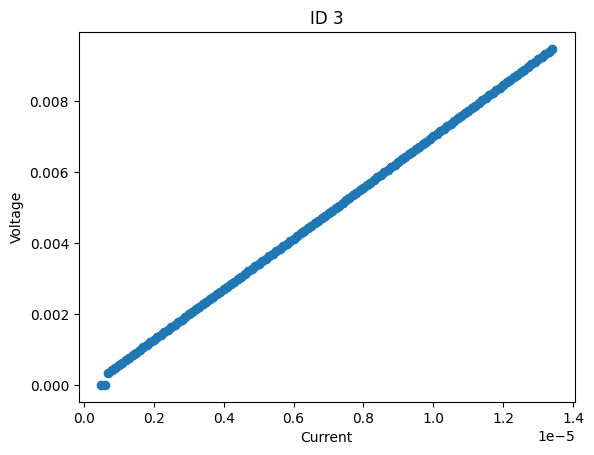

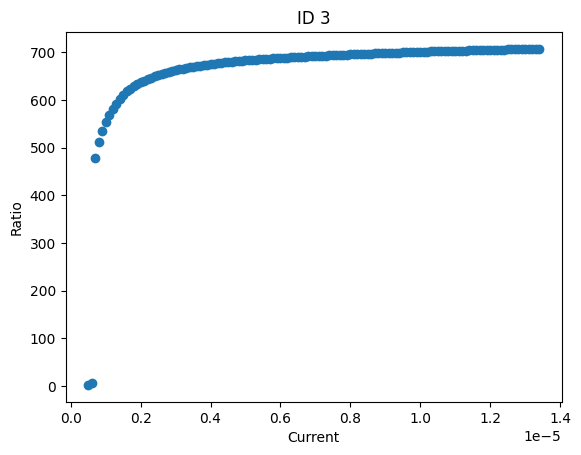

In [287]:
data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']

plt.plot(current, voltage, 'o')
plt.title(f'ID {datasaver.run_id}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {datasaver.run_id}')
plt.xlabel('Current')
plt.ylabel('Ratio')

In [292]:
# Comparing to 4K result 
current[np.where(current==0.01e-3)[0]]

array([1.e-05])

In [293]:
ratio[np.where(current==0.01e-3)[0]]

array([700.786579])

In [ ]:
MS.

Attempting dark counts

In [295]:
MS.ask('DATa:SOUrce?')

'CH1'

In [296]:
MS.data_encoding()

'RIBINARY'

In [297]:
MS.data_source()

'CH1'

##### Code for extracting single trace 
import time 
meas = Measurement()
meas.register_custom_parameter("trace", label="trace")
meas.register_custom_parameter("time_axis", label="time_axis")
meas.register_custom_parameter("trigger", label="trigger")
meas.register_custom_parameter("h_samples", label="h_samples")
meas.register_custom_parameter("samplerate", label="samplerate")
meas.register_custom_parameter("h_position_perc", label="h_position_perc")
meas.register_parameter(dmm.volt)
meas.register_parameter(yoko.current)


with meas.run() as datasaver:
    print(datasaver.run_id)

    waveform = MS.waveform_data()
    print(MS.ask('WFMOutpre?'))
    h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
    samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
    h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
    h_centre = h_samples*h_position_perc/100
    h_centre_t = h_centre/samplerate
    time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t

    datasaver.add_result(("trace", waveform),
                 ("time_axis", time_axis),
                (yoko.current, yoko.current()), 
                ("samplerate", h_samplerate), 
                ("h_samples", h_samples),
                ("h_position_perc", h_position_perc),
                ("trigger", float(MS.ask('TRIGger:A:LEVel:CH1?'))), 
                (dmm.volt, dmm.volt()))


    
print('all processes finished!')

In [299]:
h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))

In [300]:
h_samples

625000

In [301]:
samplerate

625000000.0

In [303]:
h_samples/samplerate

0.001

In [304]:
float(MS.ask('HORizontal:POSition?'))

18.2

In [306]:
MS.visa_handle.write('WFMOutpre?')
raw = MS.visa_handle.read_raw()
print(raw.decode('utf-8', errors='ignore'))

1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 512V/div, 100µs/div, 625000 points, Sample mode;625000;Y;LINEAR;"s";1.60E-9;1.5949999999953E-9;113750;"V";80.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1



0.25e-6, 0.5e-6, 0.01e-6, 0.6e-6

In [320]:
yoko.current(0.01e-6)

In [321]:
yoko.current(0.6e-6)

1e-08

In [322]:
waveform = MS.waveform_data()

h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))
h_position_perc = float(MS.ask('HORizontal:POSition?')) # percentage of trace 
h_centre = h_samples*h_position_perc/100
h_centre_t = h_centre/samplerate
time_axis = np.arange(0, h_samples, 1)/samplerate - h_centre_t


(-1.0, 1.0)

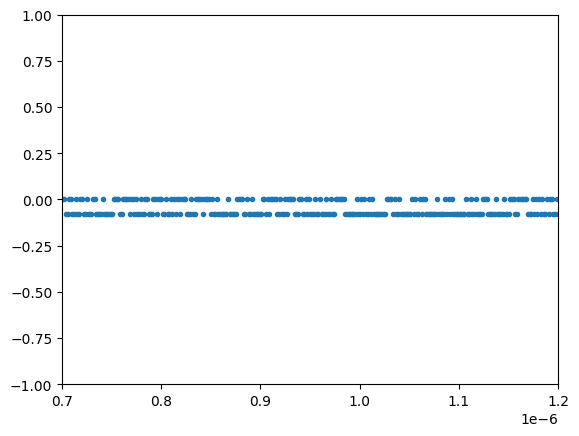

In [339]:
plt.plot(time_axis, waveform, '.')
start = 0.7e-6
plt.xlim([start, start + 0.5e-6])
plt.ylim([-1, 1])

In [325]:
time_axis[-1]-time_axis[0] # I think this is a 1ms trace 

np.float64(0.0009999984)

In [326]:
h_samples/samplerate # 1ms trace 

0.001

In [342]:
meas = Measurement()
meas.register_parameter(yoko.current)
meas.register_custom_parameter("threshold1", label="V")
meas.register_custom_parameter("threshold2", label="V")
meas.register_custom_parameter("total_counts1", label="counts")
meas.register_custom_parameter("total_counts2", label="counts")
meas.register_custom_parameter("counts1")
meas.register_custom_parameter("counts2")
meas.register_custom_parameter("trace_time", label="s")
meas.register_custom_parameter("meas_time", label="s")
meas.register_custom_parameter("bin_length", label="s")
meas.register_custom_parameter("DCR1", label="cps")
meas.register_custom_parameter("DCR2", label="cps")
meas.register_custom_parameter("n_captures")

h_samples = int(MS.ask('HORizontal:MODe:RECOrdlength?'))
samplerate = float(MS.ask('HORizontal:MODe:SAMPLERate?'))

trace_time = h_samples/samplerate
bin_length = 1 # s <-  
currents = [0.5e-6]


threshold1 = 0.75 # in volts
threshold2 = 0.5 # in volt
n_captures = 600 #<-


with meas.run() as datasaver:
    print(datasaver.run_id)

    for current in currents: 
        # Set current 
        yoko.current(current)

#         if current > 21e-6:
#             threshold1 = 2.025 # in volts
#             threshold2 = 0.5 # in volt
#             n_captures = 3600  #<-

#         elif current > 19e-6:
#             threshold1 = 1.8 # in volts
#             threshold2 = 0.5 # in volt
#             n_captures = 3600 #<-

#         elif current > 17e-6:
#             threshold1 = 1.41 # in volts
#             threshold2 = 0.5 # in volt
#             n_captures = 3600 #<-

#         elif current > 15e-6:
#             threshold1 = 1.23 # in volts
#             threshold2 = 0.5 # in volt
#             n_captures = 3600 #<-

#         elif current > 13e-6:
#             threshold1 = 0.75 # in volts
#             threshold2 = 0.5 # in volt
#             n_captures = 3600 #<-

#         elif current > 11e-6:
#             threshold1 = 0.48 # in volts
#             threshold2 = 0.425 # in volt
#             n_captures = 7200 #<-

#         else:
#             threshold1 = 0.5 # in volts
#             threshold2 = 0.4 # in volt
#             n_captures = 7200 #<-


        # Set thresholds  
        MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
        MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')

        time.sleep(5)

        # Run count 
        counts1, total_counts1, counts2, total_counts2 = count_rate_two(
        MS = MS, 
        bin_length = bin_length,
        n_captures = n_captures
        )
        
        meas_time = n_captures*trace_time
        
        DCR1 = total_counts1/meas_time
        DCR2 = total_counts2/meas_time
        
        # Save data 
        datasaver.add_result((yoko.current, yoko.current()),
                             ("threshold1", threshold1), 
                             ("threshold2", threshold2), 
                             ("total_counts1", total_counts1), 
                             ("total_counts2", total_counts2), 
                             ("counts1", counts1), 
                             ("counts2", counts2), 
                             ("trace_time", trace_time), 
                             ("meas_time", meas_time), 
                             ("bin_length", bin_length), 
                             ("n_captures", n_captures),
                             ("DCR1", DCR1), 
                             ("DCR2", DCR2))
        

print('Finished!')

Starting experimental run with id: 4. 
4
This acquisition will take 600s
Finished!


In [343]:
data = load_by_id(4).get_parameter_data()
current = data['yoko_current']['yoko_current']
threshold1 = data['threshold1']['threshold1']
threshold2 = data['threshold2']['threshold2']
total_counts1 = data['total_counts1']['total_counts1'] 
total_counts2 = data['total_counts2']['total_counts2'] 
counts1 = data['counts1']['counts1'] 
counts2 = data['counts2']['counts2'] 
trace_time = data['trace_time']['trace_time']
meas_time = data['meas_time']['meas_time']
bin_length = data['bin_length']['bin_length']
n_captures = data['n_captures']['n_captures']
DCR1 = data['DCR1']['DCR1']
DCR2 = data['DCR2']['DCR2']

In [344]:
counts1

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [ ]:
# plt.title('DDCR Square Meander (RF Line 7)\n(Fiber Connected)')
# plt.semilogy(current, DCR1, 'o')
# plt.semilogy(current, DCR2)
# plt.legend(['Threshold1 (HIGH)', 'Threshold2 (LOW)'])
# # follows the trend of SDCR

In [345]:
yoko.current()

5e-07

In [347]:
yoko.current(0)

# 12/3/26

Switch causes heating

In [348]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [352]:
import BFTC
ADDRESS = '192.168.1.2:5001'
tc = BFTC.BFTC(ADDRESS)

In [353]:
tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3

13.349

In [ ]:
# meas.register_custom_parameter("T_MXC", label="mK")

# with meas.run() as datasaver:
#     print(datasaver.run_id)
#     for i in t:
#         datasaver.add_result(("n", n()),
#                              ("T_MXC", tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3),

In [ ]:
meas.register_custom_parameter("T_MXC", label="mK")

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in t:
        datasaver.add_result(("n", n()),
                             ("T_MXC", tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3),

S1L1 Multipixel

Note: NOT at base. >8.8mK
Yoko set to 1V voltage limit

In [358]:
dmm.volt()

-1.16002501e-06

In [359]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)

currents = np.arange(1e-6, 36e-6, 1e-6)


with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Starting experimental run with id: 6. 
6
Start current 1e-06
Start current 2e-06
Start current 3e-06
Start current 4e-06
Start current 4.9999999999999996e-06
Start current 5.999999999999999e-06
Start current 7e-06
Start current 8e-06
Start current 9e-06
Start current 1e-05
Start current 1.1e-05
Start current 1.2e-05
Start current 1.3000000000000001e-05
Start current 1.4e-05
Start current 1.5e-05
Start current 1.6e-05
Start current 1.7e-05
Start current 1.8e-05
Start current 1.9e-05
Start current 1.9999999999999998e-05
Start current 2.1e-05
Start current 2.2e-05
Start current 2.3e-05
Start current 2.4e-05
Start current 2.5e-05
Start current 2.6e-05
Start current 2.7e-05
Start current 2.8e-05
Start current 2.9e-05
Start current 3e-05
Start current 3.0999999999999995e-05
Start current 3.2e-05
Start current 3.2999999999999996e-05
Start current 3.399999999999999e-05
Start current 3.5e-05
Start current 3.5999999999999994e-05
Ramping down
Current is 1e-06
Finished!


Text(0, 0.5, 'Ratio')

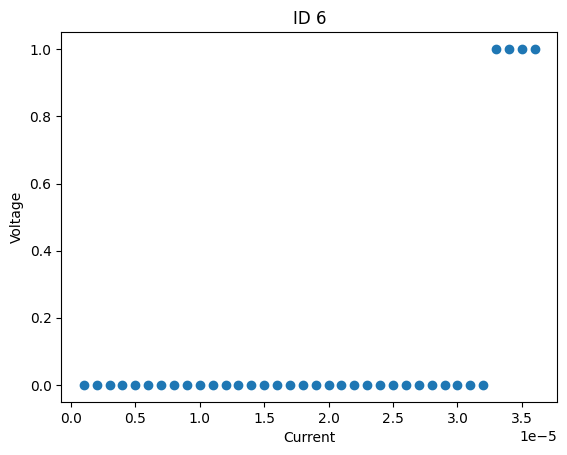

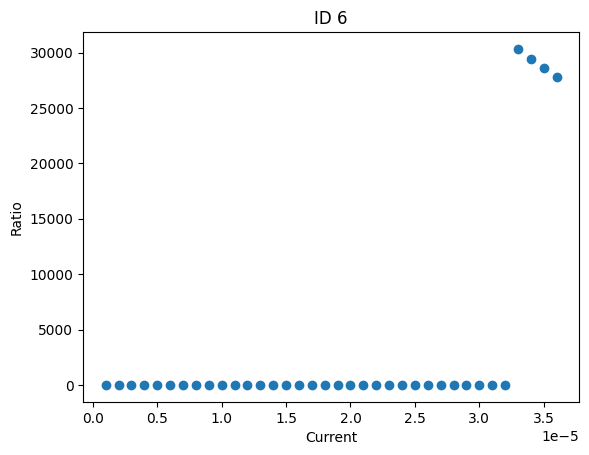

In [360]:
data = load_by_id(datasaver.run_id).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']

plt.plot(current, voltage, 'o')
plt.title(f'ID {datasaver.run_id}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {datasaver.run_id}')
plt.xlabel('Current')
plt.ylabel('Ratio')

In [361]:
tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3

TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

In [366]:
if tc.channels['MXC-flange'].measure()['temperature'][-1] == None: 
    print('Yay')

Yay


In [367]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(1e-6, 36e-6, 1e-6)


with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Starting experimental run with id: 7. 
7
Start current 1e-06
Start current 2e-06
Start current 3e-06
Start current 4e-06
Start current 4.9999999999999996e-06
Start current 5.999999999999999e-06
Start current 7e-06
Start current 8e-06
Start current 9e-06
Start current 1e-05
Start current 1.1e-05
Start current 1.2e-05
Start current 1.3000000000000001e-05
Start current 1.4e-05
Start current 1.5e-05
Start current 1.6e-05
Start current 1.7e-05
Start current 1.8e-05
Start current 1.9e-05
Start current 1.9999999999999998e-05
Start current 2.1e-05
Start current 2.2e-05
Start current 2.3e-05
Start current 2.4e-05
Start current 2.5e-05
Start current 2.6e-05
Start current 2.7e-05
Start current 2.8e-05
Start current 2.9e-05
Start current 3e-05
Start current 3.0999999999999995e-05
Start current 3.2e-05
Start current 3.2999999999999996e-05
Start current 3.399999999999999e-05
Start current 3.5e-05
Start current 3.5999999999999994e-05
Ramping down
Current is 1e-06
Finished!


Text(0, 0.5, 'Ratio')

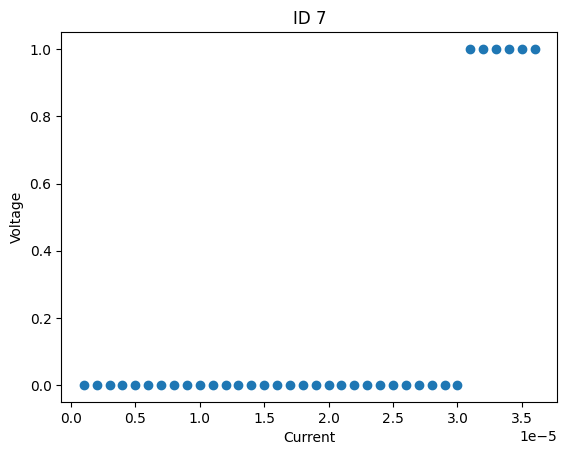

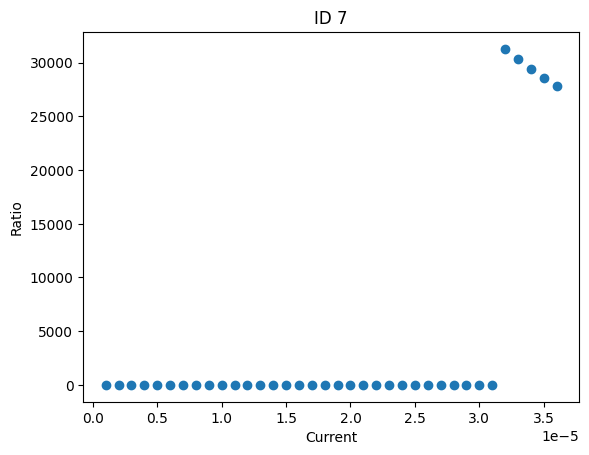

In [368]:
ID = 7
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

In [375]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(40e-6, 100e-6, 5e-6)

print('Ramp up')
ramp_up = np.arange(40e-6, 5e-6)

for i in ramp_up: 
    yoko.current(i)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Ramp up
Starting experimental run with id: 9. 
9
Start current 4e-05
Start current 4.5e-05
Start current 5e-05
Start current 5.5e-05
Start current 6e-05
Start current 6.500000000000001e-05
Start current 7e-05
Start current 7.500000000000001e-05
Start current 7.999999999999999e-05
Start current 8.5e-05
Start current 8.999999999999999e-05
Start current 9.5e-05
Ramping down
Current is 4e-05
Finished!


Text(0, 0.5, 'Ratio')

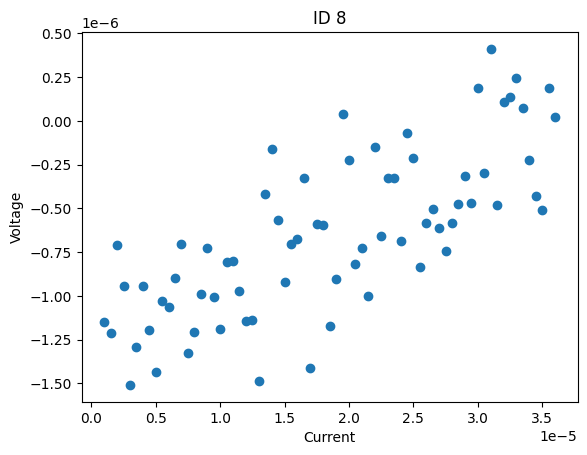

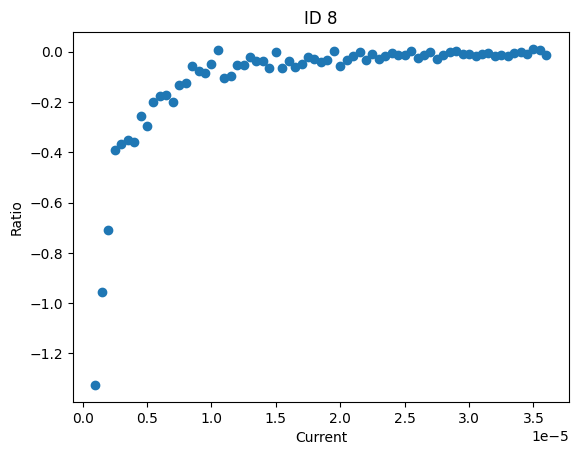

In [377]:
ID = 8
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

Text(0, 0.5, 'Ratio')

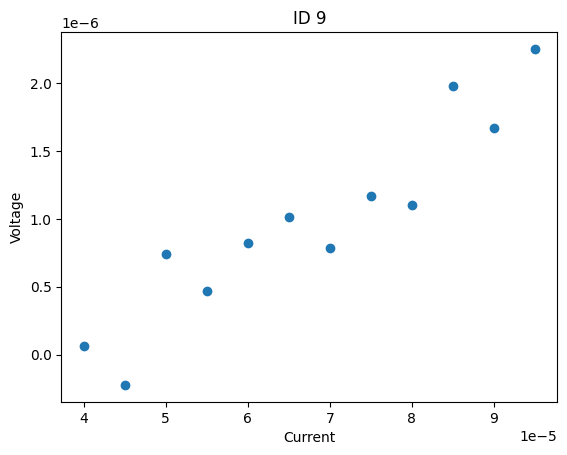

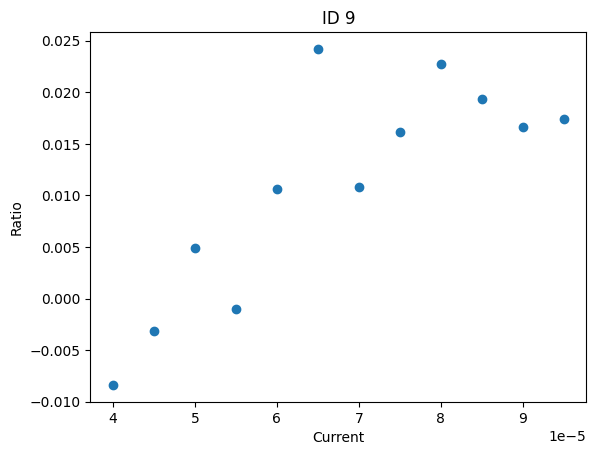

In [376]:
ID = 9
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

In [374]:
1/70e-3

14.285714285714285

In [378]:
7e-3/0.23e-3 

30.434782608695652

In [379]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(100e-6, 800e-6, 50e-6)

print('Ramp up')
ramp_up = np.arange(40e-6, 5e-6)

for i in ramp_up: 
    yoko.current(i)
    time.sleep(1)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Ramp up
Starting experimental run with id: 10. 
10
Start current 0.0001
Start current 0.00015000000000000001
Start current 0.00020000000000000004
Start current 0.00025
Start current 0.00030000000000000003
Start current 0.00035000000000000005
Start current 0.0004
Start current 0.00045000000000000004
Start current 0.0005000000000000001
Start current 0.0005500000000000001
Start current 0.0006000000000000002
Start current 0.0006500000000000002
Start current 0.0007000000000000001
Start current 0.0007500000000000001
Ramping down
Current is 0.0001
Finished!


Text(0, 0.5, 'Ratio')

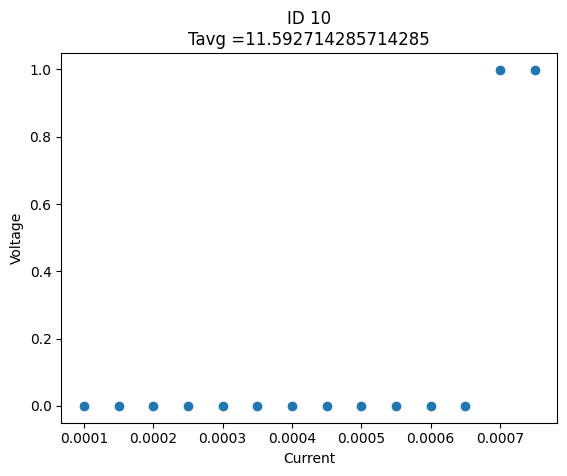

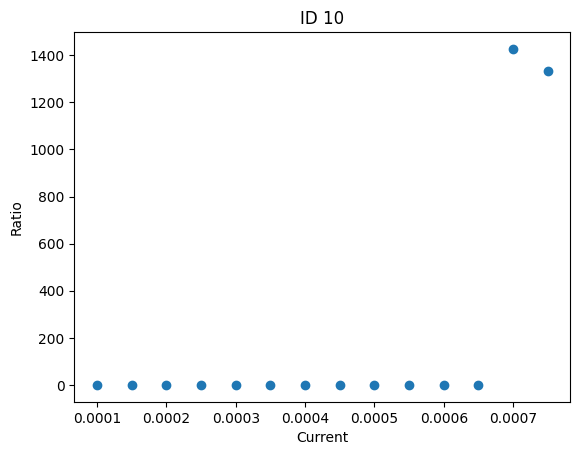

In [400]:
ID = 10
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}\nTavg ={t_avg}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

In [382]:
Ic = 0.7e-3
R = 100e3 
print(Ic*R) 

70.0


In [383]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(100e-6, 1000e-6, 50e-6)

print('Ramp up')
ramp_up = np.arange(40e-6, 5e-6)

for i in ramp_up: 
    yoko.current(i)
    time.sleep(1)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Ramp up
Starting experimental run with id: 11. 
11
Start current 0.0001
Start current 0.00015000000000000001
Start current 0.00020000000000000004
Start current 0.00025
Start current 0.00030000000000000003
Start current 0.00035000000000000005
Start current 0.0004
Start current 0.00045000000000000004
Start current 0.0005000000000000001
Start current 0.0005500000000000001
Start current 0.0006000000000000002
Start current 0.0006500000000000002
Start current 0.0007000000000000001
Start current 0.0007500000000000001
Start current 0.0008000000000000001
Start current 0.0008500000000000002
Start current 0.0009000000000000002
Start current 0.0009500000000000002
Ramping down
Current is 0.0001
Finished!


Text(0, 0.5, 'Ratio')

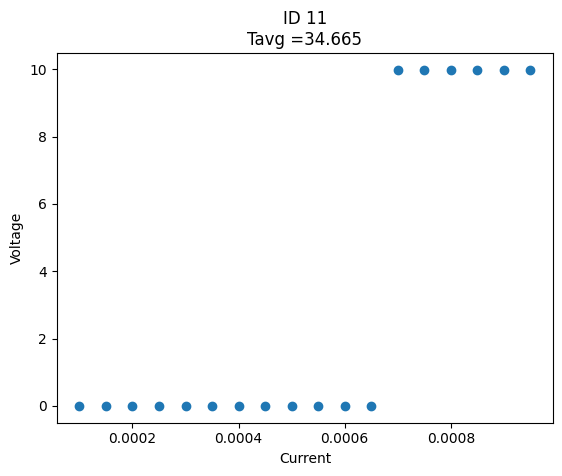

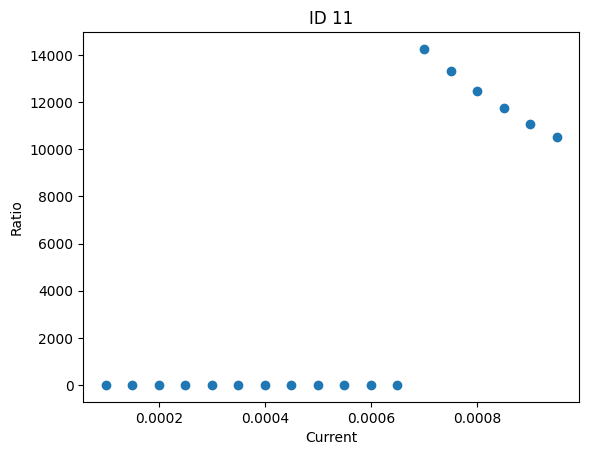

In [399]:
ID = 11
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}\nTavg ={t_avg}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

100kOhm resistance for 1mA

In [385]:
1e-3*100e3 

100.0

The previous sweep and observation with Yoko current limit at 20V for 1mA caused heating (mxc is 100mK) now 

In [386]:
R = 121.3
I = 1e-3
print(I*R)

0.1213


In [387]:
10/1e-3 # what we measure across yoko

10000.0

In [390]:
ramp_up = np.arange(0, 100e-6, 5e-6)
for i in ramp_up: 
    print(i)
    time.sleep(1)

0.0
5e-06
1e-05
1.5000000000000002e-05
2e-05
2.5e-05
3.0000000000000004e-05
3.5000000000000004e-05
4e-05
4.5e-05
5e-05
5.5e-05
6.000000000000001e-05
6.500000000000001e-05
7.000000000000001e-05
7.500000000000001e-05
8e-05
8.5e-05
9e-05
9.5e-05


In [391]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(100e-6, 1000e-6, 50e-6)

print('Ramp up')
ramp_up = np.arange(0, 100e-6, 5e-6)

for i in ramp_up: 
    yoko.current(i)
    time.sleep(1)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Ramp up
Starting experimental run with id: 12. 
12
Start current 0.0001
Start current 0.00015000000000000001
Start current 0.00020000000000000004
Start current 0.00025
Start current 0.00030000000000000003
Start current 0.00035000000000000005
Start current 0.0004
Start current 0.00045000000000000004
Start current 0.0005000000000000001
Start current 0.0005500000000000001
Start current 0.0006000000000000002
Start current 0.0006500000000000002
Start current 0.0007000000000000001
Start current 0.0007500000000000001
Start current 0.0008000000000000001
Start current 0.0008500000000000002
Start current 0.0009000000000000002
Start current 0.0009500000000000002
Ramping down
Current is 0.0001
Finished!


Text(0, 0.5, 'Ratio')

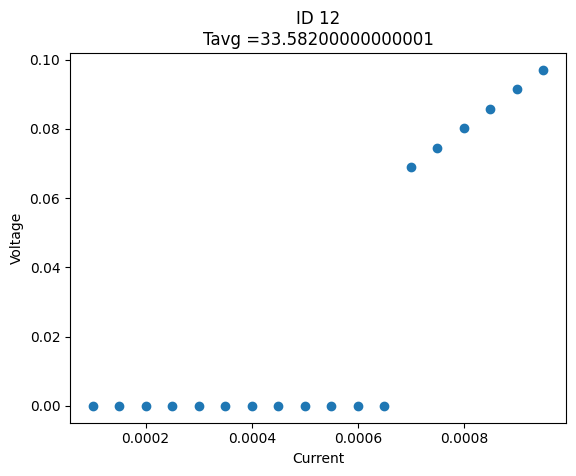

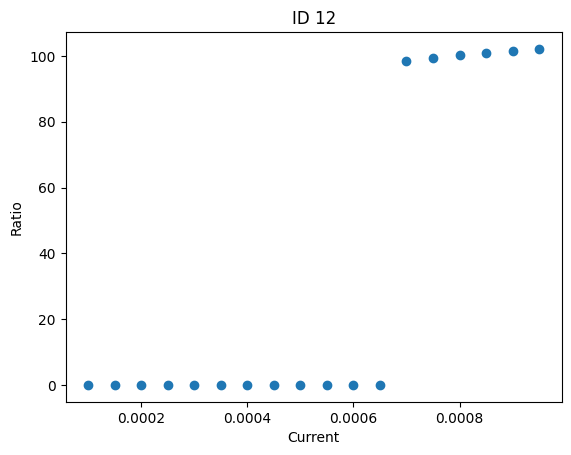

In [398]:
ID = 12
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}\nTavg ={t_avg}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

What ??? 20V limit and it didn't even go to 10??? Didn't even go to 1? 

Running again same conditions

In [393]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(100e-6, 1000e-6, 50e-6)

print('Ramp up')
ramp_up = np.arange(0, 100e-6, 5e-6)

for i in ramp_up: 
    yoko.current(i)
    time.sleep(1)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Ramp up
Starting experimental run with id: 13. 
13
Start current 0.0001
Start current 0.00015000000000000001
Start current 0.00020000000000000004
Start current 0.00025
Start current 0.00030000000000000003
Start current 0.00035000000000000005
Start current 0.0004
Start current 0.00045000000000000004
Start current 0.0005000000000000001
Start current 0.0005500000000000001
Start current 0.0006000000000000002
Start current 0.0006500000000000002
Start current 0.0007000000000000001
Start current 0.0007500000000000001
Start current 0.0008000000000000001
Start current 0.0008500000000000002
Start current 0.0009000000000000002
Start current 0.0009500000000000002
Ramping down
Current is 0.0001
Finished!


Text(0, 0.5, 'Ratio')

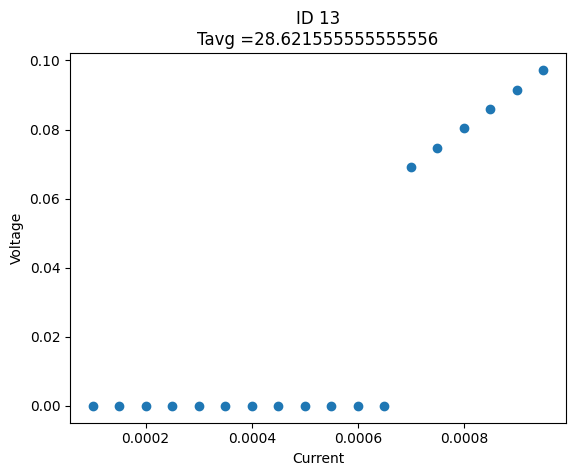

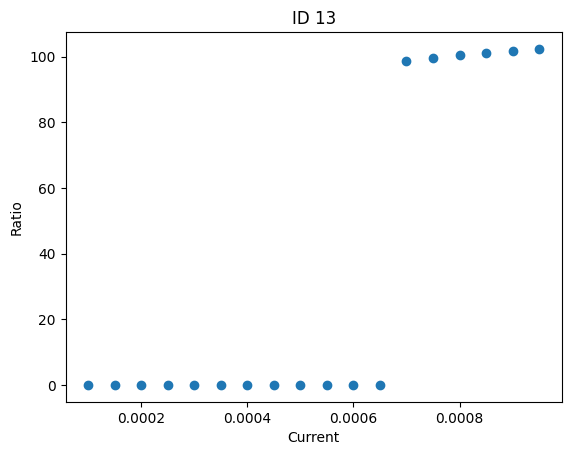

In [397]:
ID = 13
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}\nTavg ={t_avg}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

Running again with 1V limit. Expecting no change. Shouldn't affect anything. 

In [401]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(100e-6, 1000e-6, 50e-6)

print('Ramp up')
ramp_up = np.arange(0, 100e-6, 5e-6)

for i in ramp_up: 
    yoko.current(i)
    time.sleep(1)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Ramp up
Starting experimental run with id: 14. 
14
Start current 0.0001
Start current 0.00015000000000000001
Start current 0.00020000000000000004
Start current 0.00025
Start current 0.00030000000000000003
Start current 0.00035000000000000005
Start current 0.0004
Start current 0.00045000000000000004
Start current 0.0005000000000000001
Start current 0.0005500000000000001
Start current 0.0006000000000000002
Start current 0.0006500000000000002
Start current 0.0007000000000000001
Start current 0.0007500000000000001
Start current 0.0008000000000000001
Start current 0.0008500000000000002
Start current 0.0009000000000000002
Start current 0.0009500000000000002
Ramping down
Current is 0.0001
Finished!


Text(0, 0.5, 'Ratio')

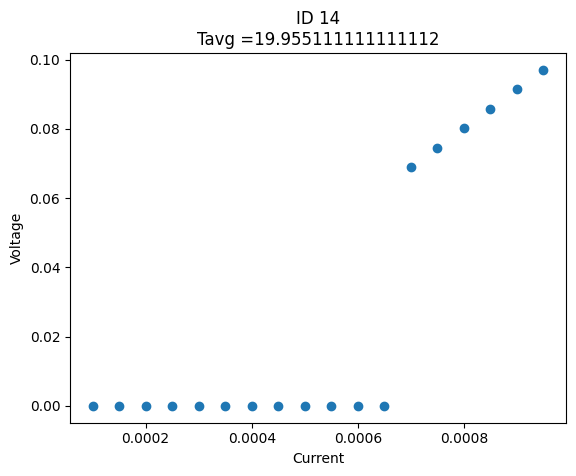

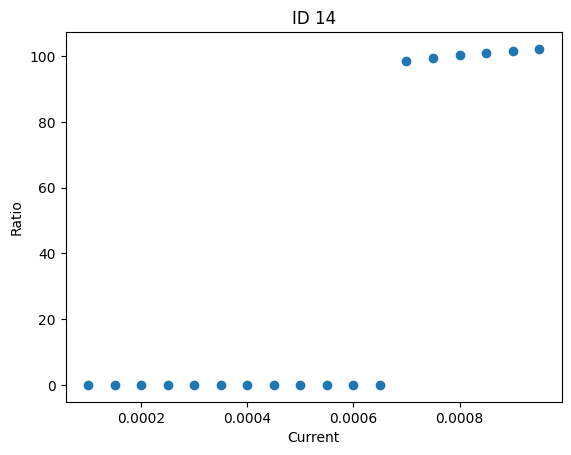

In [402]:
ID = 14
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}\nTavg ={t_avg}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

Fine sweep

In [406]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(400e-6, 1000e-6, 5e-6)

print('Ramp up')
ramp_up = np.arange(0, 400e-6, 50e-6)

for i in ramp_up: 
    yoko.current(i)
    time.sleep(1)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Ramp up
Starting experimental run with id: 16. 
16
Start current 0.0004
Start current 0.00040500000000000003
Start current 0.00041000000000000005
Start current 0.00041500000000000006
Start current 0.00042000000000000007
Start current 0.0004250000000000001
Start current 0.0004300000000000001
Start current 0.0004350000000000001
Start current 0.0004400000000000001
Start current 0.00044500000000000014
Start current 0.00045000000000000015
Start current 0.00045500000000000016
Start current 0.0004600000000000002
Start current 0.0004650000000000002
Start current 0.0004700000000000002
Start current 0.0004750000000000002
Start current 0.00048000000000000023
Start current 0.00048500000000000024
Start current 0.0004900000000000002
Start current 0.0004950000000000002
Start current 0.0005000000000000002
Start current 0.0005050000000000002
Start current 0.0005100000000000003
Start current 0.0005150000000000003
Start current 0.0005200000000000003
Start current 0.0005250000000000003
Start current 0.000

Text(0, 0.5, 'Ratio')

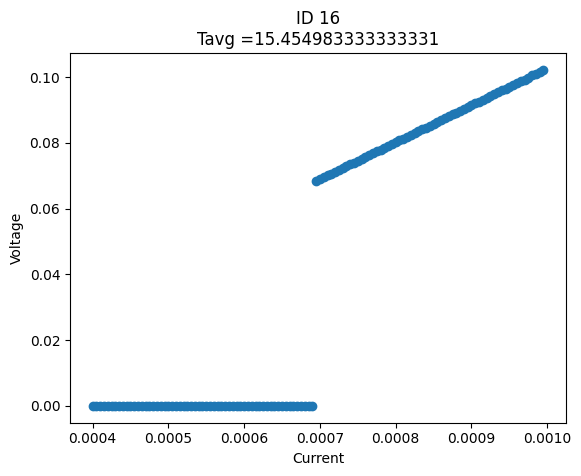

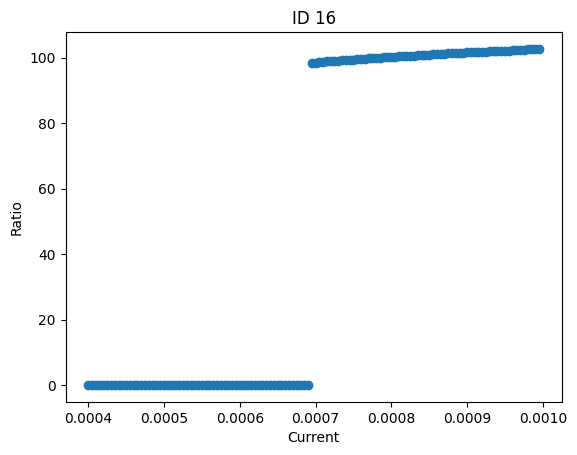

In [407]:
ID = 16
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}\nTavg ={t_avg}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

After attempt to switch. Runnning coarse sweep for R5C11 again. 

In [408]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(100e-6, 1000e-6, 50e-6)

print('Ramp up')
ramp_up = np.arange(0, 100e-6, 5e-6)

for i in ramp_up: 
    yoko.current(i)
    time.sleep(1)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Ramp up
Starting experimental run with id: 17. 
17
Start current 0.0001
Start current 0.00015000000000000001
Start current 0.00020000000000000004
Start current 0.00025
Start current 0.00030000000000000003
Start current 0.00035000000000000005
Start current 0.0004
Start current 0.00045000000000000004
Start current 0.0005000000000000001
Start current 0.0005500000000000001
Start current 0.0006000000000000002
Start current 0.0006500000000000002
Start current 0.0007000000000000001
Start current 0.0007500000000000001
Start current 0.0008000000000000001
Start current 0.0008500000000000002
Start current 0.0009000000000000002
Start current 0.0009500000000000002
Ramping down
Current is 0.0001
Finished!


Text(0, 0.5, 'Ratio')

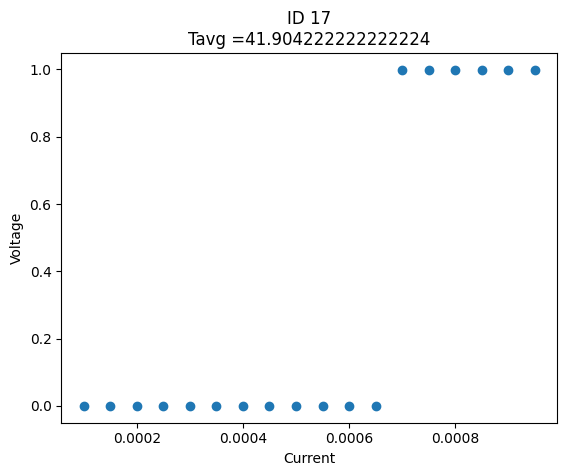

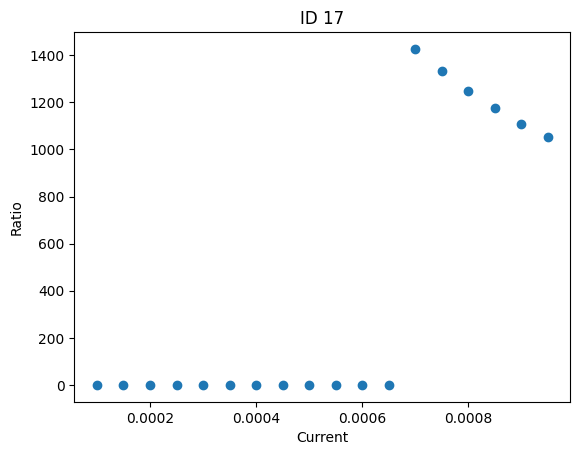

In [409]:
ID = 17
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}\nTavg ={t_avg}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

R5C7 S1 Line 4 S2 Line 1


REpeat the sweep from Tuesday  (ID 2)

In [410]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(0.01e-6, 2.03e-6, 0.05e-6)


with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Starting experimental run with id: 18. 
18
Start current 1e-08
Start current 6e-08
Start current 1.0999999999999999e-07
Start current 1.6e-07
Start current 2.1e-07
Start current 2.6e-07
Start current 3.1e-07
Start current 3.6e-07
Start current 4.1e-07
Start current 4.6e-07
Start current 5.1e-07
Start current 5.6e-07
Start current 6.1e-07
Start current 6.599999999999999e-07
Start current 7.1e-07
Start current 7.6e-07
Start current 8.1e-07
Start current 8.599999999999999e-07
Start current 9.1e-07
Start current 9.6e-07
Start current 1.0099999999999999e-06
Start current 1.0599999999999998e-06
Start current 1.11e-06
Start current 1.16e-06
Start current 1.2099999999999998e-06
Start current 1.2599999999999998e-06
Start current 1.3099999999999997e-06
Start current 1.36e-06
Start current 1.4099999999999998e-06
Start current 1.4599999999999998e-06
Start current 1.51e-06
Start current 1.5599999999999999e-06
Start current 1.6099999999999998e-06
Start current 1.6599999999999998e-06
Start current 1.

Text(0, 0.5, 'Ratio')

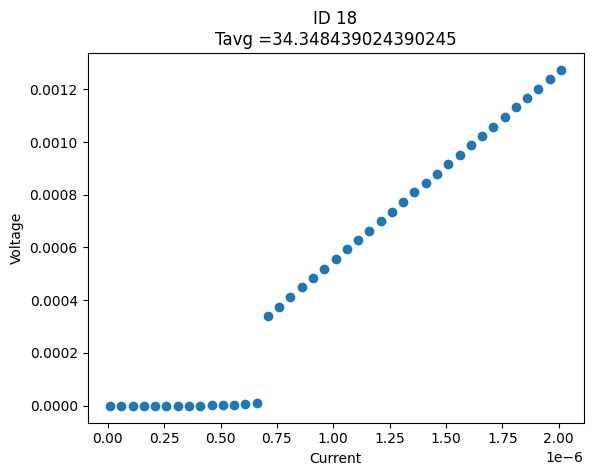

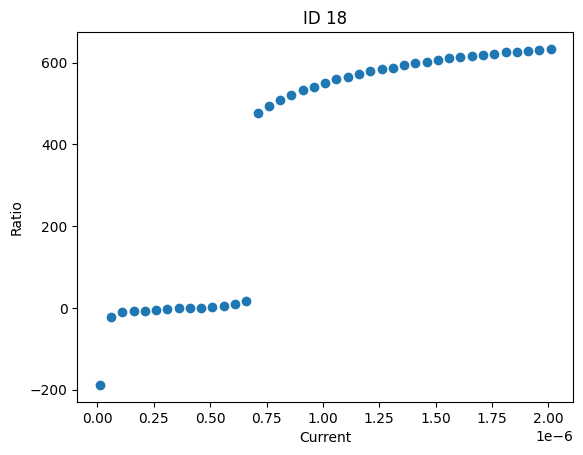

In [411]:
ID = 18
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}\nTavg ={t_avg}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

WIder sweep 

In [412]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(0.01e-6,10e-6, 0.5e-6)


with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Starting experimental run with id: 19. 
19
Start current 1e-08
Start current 5.1e-07
Start current 1.0099999999999999e-06
Start current 1.51e-06
Start current 2.01e-06
Start current 2.5099999999999997e-06
Start current 3.01e-06
Start current 3.51e-06
Start current 4.01e-06
Start current 4.51e-06
Start current 5.0099999999999995e-06
Start current 5.51e-06
Start current 6.01e-06
Start current 6.5099999999999995e-06
Start current 7.01e-06
Start current 7.509999999999999e-06
Start current 8.01e-06
Start current 8.51e-06
Start current 9.01e-06
Start current 9.509999999999999e-06
Ramping down
Current is 1e-08
Finished!


Text(0, 0.5, 'Ratio')

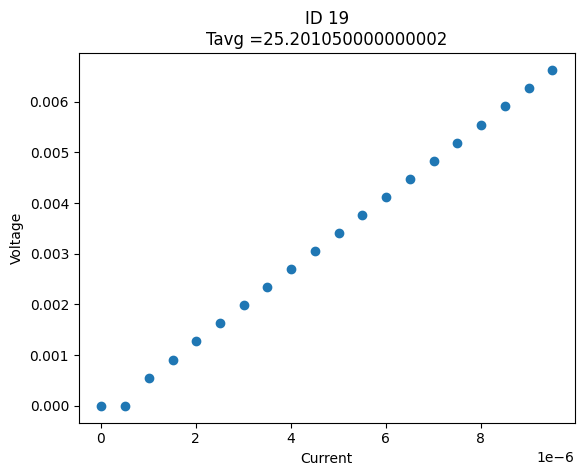

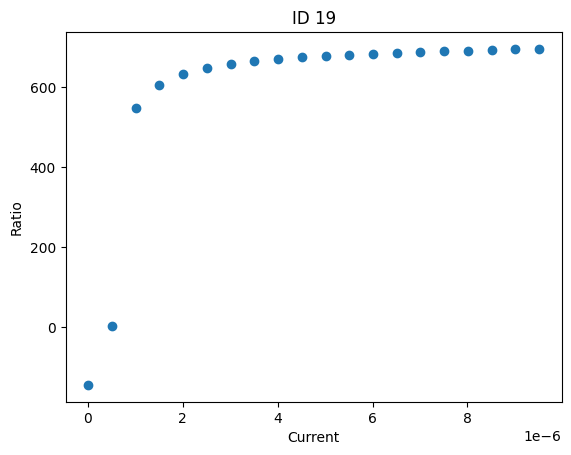

In [414]:
ID = 19
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}\nTavg ={t_avg}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

Switch device off and back on again (current source off first) 

In [415]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(0.01e-6, 2.03e-6, 0.05e-6)


with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Starting experimental run with id: 20. 
20
Start current 1e-08
Start current 6e-08
Start current 1.0999999999999999e-07
Start current 1.6e-07
Start current 2.1e-07
Start current 2.6e-07
Start current 3.1e-07
Start current 3.6e-07
Start current 4.1e-07
Start current 4.6e-07
Start current 5.1e-07
Start current 5.6e-07
Start current 6.1e-07
Start current 6.599999999999999e-07
Start current 7.1e-07
Start current 7.6e-07
Start current 8.1e-07
Start current 8.599999999999999e-07
Start current 9.1e-07
Start current 9.6e-07
Start current 1.0099999999999999e-06
Start current 1.0599999999999998e-06
Start current 1.11e-06
Start current 1.16e-06
Start current 1.2099999999999998e-06
Start current 1.2599999999999998e-06
Start current 1.3099999999999997e-06
Start current 1.36e-06
Start current 1.4099999999999998e-06
Start current 1.4599999999999998e-06
Start current 1.51e-06
Start current 1.5599999999999999e-06
Start current 1.6099999999999998e-06
Start current 1.6599999999999998e-06
Start current 1.

Text(0, 0.5, 'Ratio')

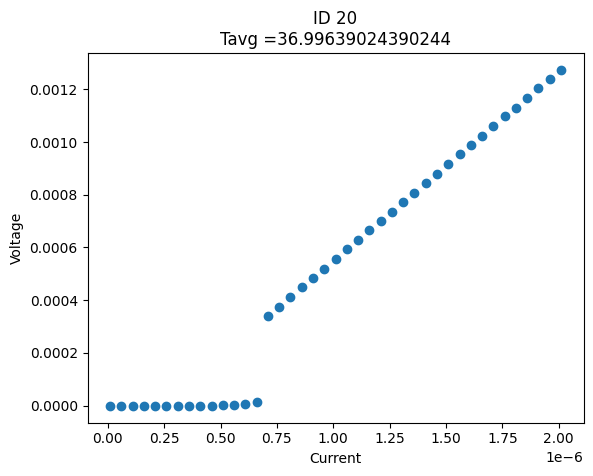

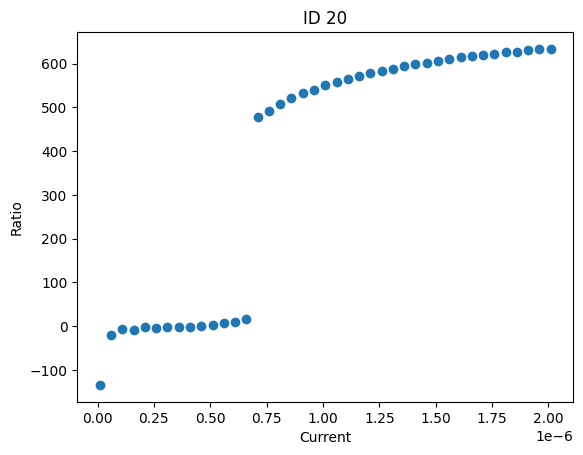

In [416]:
ID = 20
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}\nTavg ={t_avg}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

Try switching to the other device again, turning off the current source first. Run same parameters as ID 16, 1V limit on yoko.

In [418]:
import numpy as np
import time

# initialize measurement 
meas = Measurement()
meas.register_custom_parameter("ratio")
meas.register_parameter(yoko.current)
meas.register_parameter(dmm.volt)
meas.register_custom_parameter("T_MXC", label="mK")

currents = np.arange(400e-6, 1000e-6, 5e-6)

print('Ramp up')
ramp_up = np.arange(0, 400e-6, 50e-6)

for i in ramp_up: 
    yoko.current(i)
    time.sleep(1)

with meas.run() as datasaver:
    print(datasaver.run_id)
    for i in currents:
        print(f'Start current {i}')
        yoko.current(i)
        time.sleep(2)
        if i == 0: 
            ratio = 0
        else: 
            ratio = dmm.volt()/yoko.current()
        
        if tc.channels['MXC-flange'].measure()['temperature'][-1] == None:
            temp = -1
        else: 
            temp = tc.channels['MXC-flange'].measure()['temperature'][-1]*1e3
        
        datasaver.add_result(('ratio',ratio),
                            (dmm.volt, dmm.volt()),
                            (yoko.current, yoko.current()), 
                            ("T_MXC", temp))
        time.sleep(0.1)

print('Ramping down')

for i in currents[::-1]: 
    yoko.current(i)
    time.sleep(0.1)

print(f'Current is {yoko.current()}')

print('Finished!')


Ramp up
Starting experimental run with id: 21. 
21
Start current 0.0004
Start current 0.00040500000000000003
Start current 0.00041000000000000005
Start current 0.00041500000000000006
Start current 0.00042000000000000007
Start current 0.0004250000000000001
Start current 0.0004300000000000001
Start current 0.0004350000000000001
Start current 0.0004400000000000001
Start current 0.00044500000000000014
Start current 0.00045000000000000015
Start current 0.00045500000000000016
Start current 0.0004600000000000002
Start current 0.0004650000000000002
Start current 0.0004700000000000002
Start current 0.0004750000000000002
Start current 0.00048000000000000023
Start current 0.00048500000000000024
Start current 0.0004900000000000002
Start current 0.0004950000000000002
Start current 0.0005000000000000002
Start current 0.0005050000000000002
Start current 0.0005100000000000003
Start current 0.0005150000000000003
Start current 0.0005200000000000003
Start current 0.0005250000000000003
Start current 0.000

Text(0, 0.5, 'Ratio')

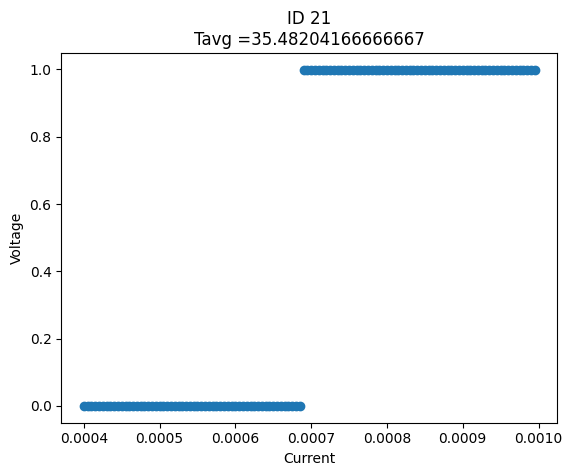

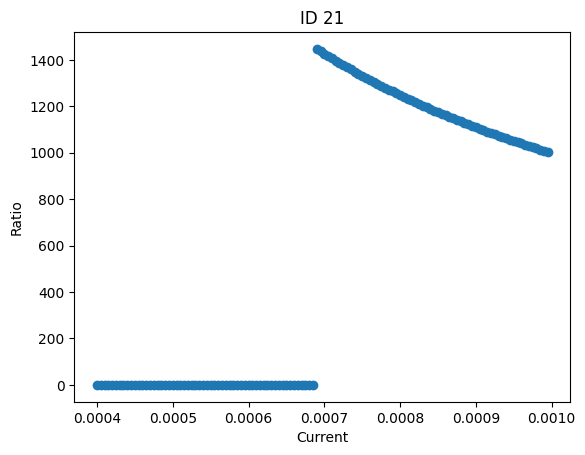

In [419]:
ID = 21
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
ratio = data['ratio']['ratio']
t_avg = np.average(data['T_MXC']['T_MXC'])


plt.plot(current, voltage, 'o')
plt.title(f'ID {ID}\nTavg ={t_avg}')
plt.xlabel('Current')
plt.ylabel('Voltage')

plt.figure()
plt.plot(current, ratio, 'o')
plt.title(f'ID {ID}')
plt.xlabel('Current')
plt.ylabel('Ratio')

In [1]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

NameError: name 'laser' is not defined